In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from datetime import date


# ============================================================
# Settings
# ============================================================

BASE_DIR = Path("/nird/datalake/NS11071K/users/yongyub/Observation")

XRO_FILE = (
    BASE_DIR / "ORAS5" / "XRO_input" /
    "ORAS5_XRO_input_indices_1998_2025_component_anom_then_detrend_deg1.nc"
)

# New PP regional mean file based on valid zero30 RECCAP all-region mask
PP_FILE = (
    BASE_DIR / "GlobColour" /
    "RECCAP2_all_regions_valid_zero30_region_mean_PP" /
    "GlobColour_PP_RECCAP2_all_regions_valid_zero30_area_mean_1998_2025.nc"
)

OUT_DIR = Path("/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Main PP variable:
#   "PP"            = invalid monthly values within retained mask are zero-filled
#   "PP_valid_only" = monthly invalid values are excluded from denominator
PP_VAR = "PP"

OUT_FILE = OUT_DIR / (
    f"Cyclostationary_LIM_ORAS5_XRO10_GlobColour_"
    f"{PP_VAR}_RECCAP2_all_regions_valid_zero30_1998_2025.nc"
)

# Use standardized ORAS5 XRO inputs
XRO_VAR = "xro_input_standardized"

# PP preprocessing
PP_TREND_DEGREE = 1
REF_START = "1998-01-01"
REF_END   = "2025-12-31"

# LIM settings
RIDGE_ALPHA = 1.0e-3
MIN_SAMPLES = 12

STATE_ORDER = [
    "PP",
    "TENSO",
    "WWV",
    "NPMM",
    "SPMM",
    "IOB",
    "IOD",
    "SIOD",
    "TNA",
    "ATL3",
    "SASD",
]


# ============================================================
# Helper functions
# ============================================================

def decode_str_array(values):
    """
    Convert netCDF string / byte-string arrays to Python strings.
    """
    out = []
    for v in values:
        if isinstance(v, bytes):
            out.append(v.decode("utf-8"))
        else:
            out.append(str(v))
    return np.array(out, dtype=object)


def remove_monthly_climatology(x, ref_start, ref_end):
    """
    Remove monthly climatology.

    x dims can be:
        time, region
        time, mode
    """
    x_ref = x.sel(time=slice(ref_start, ref_end))
    clim = x_ref.groupby("time.month").mean("time", skipna=True)
    anom = x.groupby("time.month") - clim
    return anom, clim


def polynomial_detrend_by_dim(x, feature_dim, ref_start, ref_end, degree=1):
    """
    Remove polynomial trend independently along feature_dim.

    x dims: time, feature_dim
    """
    x_fit = x.sel(time=slice(ref_start, ref_end))

    time_all = pd.to_datetime(x["time"].values)
    time_fit = pd.to_datetime(x_fit["time"].values)

    t0 = time_fit[0]
    t_all = ((time_all - t0) / np.timedelta64(1, "D")) / 365.25
    t_fit = ((time_fit - t0) / np.timedelta64(1, "D")) / 365.25

    out = xr.full_like(x, np.nan)
    trend = xr.full_like(x, np.nan)

    coeffs = []

    for val in x[feature_dim].values:
        y_fit = x_fit.sel({feature_dim: val}).values.astype(float)
        ok = np.isfinite(y_fit)

        if ok.sum() < degree + 2:
            coef = np.full(degree + 1, np.nan)
            coeffs.append(coef)
            continue

        coef = np.polyfit(t_fit[ok], y_fit[ok], deg=degree)
        tr = np.polyval(coef, t_all)

        y_all = x.sel({feature_dim: val}).values.astype(float)

        trend.loc[{feature_dim: val}] = tr
        out.loc[{feature_dim: val}] = y_all - tr

        coeffs.append(coef)

    coeff_da = xr.DataArray(
        np.asarray(coeffs),
        dims=(feature_dim, "poly_coeff"),
        coords={
            feature_dim: x[feature_dim].values,
            "poly_coeff": np.arange(degree + 1),
        },
        name="trend_coefficients",
        attrs={
            "description": (
                "numpy.polyfit coefficients. For degree=1, coeff[0] is slope per year."
            ),
            "trend_time_origin": str(t0),
        },
    )

    return out, trend, coeff_da


def standardize_by_dim(x, feature_dim, ref_start, ref_end):
    """
    Standardize each feature independently.
    """
    x_ref = x.sel(time=slice(ref_start, ref_end))

    mean = x_ref.mean("time", skipna=True)
    std = x_ref.std("time", skipna=True)

    # Avoid divide-by-zero
    std = xr.where(std > 0, std, np.nan)

    z = (x - mean) / std

    return z, mean, std


def fit_cyclostationary_lim_one_region(X, months, ridge_alpha=1e-3, min_samples=12):
    """
    Fit monthly LIM transition matrices.

    X shape: time, state
    months shape: time
    G_m maps X(t) -> X(t+1), grouped by month of X(t).

    Returns:
        G[month, state_to, state_from]
        C0[month, state, state]
        C1[month, state_to, state_from]
        Q[month, state, state]
        n_samples[month]
        fit_mean_x[month, state]
        fit_mean_y[month, state]
    """
    ntime, nstate = X.shape

    G = np.full((12, nstate, nstate), np.nan, dtype=np.float64)
    C0 = np.full((12, nstate, nstate), np.nan, dtype=np.float64)
    C1 = np.full((12, nstate, nstate), np.nan, dtype=np.float64)
    Q = np.full((12, nstate, nstate), np.nan, dtype=np.float64)

    n_samples = np.zeros(12, dtype=np.int16)
    fit_mean_x = np.full((12, nstate), np.nan, dtype=np.float64)
    fit_mean_y = np.full((12, nstate), np.nan, dtype=np.float64)

    for m in range(1, 13):
        idx = np.where(months[:-1] == m)[0]

        X0 = X[idx, :]
        X1 = X[idx + 1, :]

        good = np.isfinite(X0).all(axis=1) & np.isfinite(X1).all(axis=1)

        X0 = X0[good, :]
        X1 = X1[good, :]

        n = X0.shape[0]
        n_samples[m - 1] = n

        if n < min_samples:
            continue

        mx = X0.mean(axis=0)
        my = X1.mean(axis=0)

        X0c = X0 - mx
        X1c = X1 - my

        fit_mean_x[m - 1, :] = mx
        fit_mean_y[m - 1, :] = my

        Sxx = (X0c.T @ X0c) / max(n - 1, 1)
        Syx = (X1c.T @ X0c) / max(n - 1, 1)

        scale = np.nanmean(np.diag(Sxx))
        if not np.isfinite(scale) or scale <= 0:
            scale = 1.0

        ridge = ridge_alpha * scale
        A = Sxx + ridge * np.eye(nstate)

        # G = Syx @ inv(A)
        Gm = np.linalg.solve(A.T, Syx.T).T

        residual = X1c - X0c @ Gm.T
        Qm = (residual.T @ residual) / max(n - 1, 1)

        G[m - 1, :, :] = Gm
        C0[m - 1, :, :] = Sxx
        C1[m - 1, :, :] = Syx
        Q[m - 1, :, :] = Qm

    return G, C0, C1, Q, n_samples, fit_mean_x, fit_mean_y


# ============================================================
# Load data
# ============================================================

ds_xro = xr.open_dataset(XRO_FILE)
ds_pp = xr.open_dataset(PP_FILE)

if XRO_VAR not in ds_xro:
    raise KeyError(f"{XRO_VAR} not found in {XRO_FILE}")

if PP_VAR not in ds_pp:
    raise KeyError(f"{PP_VAR} not found in {PP_FILE}")

xro = ds_xro[XRO_VAR].sel(mode=STATE_ORDER[1:]).sortby("time")
pp_raw = ds_pp[PP_VAR].sortby("time")

# Keep only regions with at least one finite value
finite_region = np.isfinite(pp_raw).any("time")
pp_raw = pp_raw.sel(region=pp_raw["region"].where(finite_region, drop=True))

# Align common time axis
pp_raw, xro = xr.align(pp_raw, xro, join="inner")

print("Common period:")
print(str(pp_raw["time"].values[0]), "to", str(pp_raw["time"].values[-1]))
print("ntime:", pp_raw.sizes["time"])
print("nregion:", pp_raw.sizes["region"])
print("PP variable:", PP_VAR)
print("XRO modes:", list(xro["mode"].values))


# ============================================================
# Preprocess PP in XRO-like way
# ============================================================

pp_anom, pp_monthly_clim = remove_monthly_climatology(
    pp_raw,
    REF_START,
    REF_END,
)

pp_detrended, pp_removed_trend, pp_trend_coeff = polynomial_detrend_by_dim(
    pp_anom,
    feature_dim="region",
    ref_start=REF_START,
    ref_end=REF_END,
    degree=PP_TREND_DEGREE,
)

pp_std, pp_std_mean, pp_std_dev = standardize_by_dim(
    pp_detrended,
    feature_dim="region",
    ref_start=REF_START,
    ref_end=REF_END,
)

# Drop regions that became all-NaN after standardization
finite_region_after_std = np.isfinite(pp_std).any("time")
pp_std = pp_std.sel(region=pp_std["region"].where(finite_region_after_std, drop=True))
pp_detrended = pp_detrended.sel(region=pp_std["region"])
pp_anom = pp_anom.sel(region=pp_std["region"])
pp_monthly_clim = pp_monthly_clim.sel(region=pp_std["region"])
pp_removed_trend = pp_removed_trend.sel(region=pp_std["region"])
pp_std_mean = pp_std_mean.sel(region=pp_std["region"])
pp_std_dev = pp_std_dev.sel(region=pp_std["region"])
pp_trend_coeff = pp_trend_coeff.sel(region=pp_std["region"])

pp_std.name = "PP_xro_like_standardized"
pp_detrended.name = "PP_xro_like"
pp_anom.name = "PP_monthly_anomaly"


# ============================================================
# Build state vector: region, time, state
# ============================================================

regions = pp_std["region"].values.astype(np.int16)
times = pp_std["time"].values
months = pd.to_datetime(times).month.values.astype(np.int16)

n_region = len(regions)
n_time = len(times)
n_state = len(STATE_ORDER)

state_values = np.full((n_region, n_time, n_state), np.nan, dtype=np.float32)

for ir, reg in enumerate(regions):
    state_values[ir, :, 0] = pp_std.sel(region=reg).values.astype(np.float32)

    for istd, mode in enumerate(STATE_ORDER[1:], start=1):
        state_values[ir, :, istd] = xro.sel(mode=mode).values.astype(np.float32)

state_vector = xr.DataArray(
    state_values,
    dims=("region", "time", "state"),
    coords={
        "region": regions,
        "time": times,
        "state": STATE_ORDER,
    },
    name="state_vector",
    attrs={
        "long_name": "Standardized state vector for regional cyclostationary LIM",
        "description": (
            "For each retained RECCAP2 all-region mask region, the state vector is "
            "[regional PP, ORAS5 XRO 10 modes]. PP is monthly-climatology-removed, "
            "linear-detrended, and standardized. ORAS5 XRO modes are read from "
            f"{XRO_VAR}."
        ),
        "units": "standard deviation",
    },
)


# ============================================================
# Fit cyclostationary LIM by region
# ============================================================

G_all = np.full((n_region, 12, n_state, n_state), np.nan, dtype=np.float64)
C0_all = np.full_like(G_all, np.nan)
C1_all = np.full_like(G_all, np.nan)
Q_all = np.full_like(G_all, np.nan)

n_samples_all = np.zeros((n_region, 12), dtype=np.int16)
fit_mean_x_all = np.full((n_region, 12, n_state), np.nan, dtype=np.float64)
fit_mean_y_all = np.full((n_region, 12, n_state), np.nan, dtype=np.float64)

for ir, reg in enumerate(regions):
    print(f"[{ir+1:02d}/{n_region:02d}] fitting region {int(reg)}")

    X = state_vector.sel(region=reg).values.astype(np.float64)

    G, C0, C1, Q, n_samples, mx, my = fit_cyclostationary_lim_one_region(
        X,
        months,
        ridge_alpha=RIDGE_ALPHA,
        min_samples=MIN_SAMPLES,
    )

    G_all[ir] = G
    C0_all[ir] = C0
    C1_all[ir] = C1
    Q_all[ir] = Q

    n_samples_all[ir] = n_samples
    fit_mean_x_all[ir] = mx
    fit_mean_y_all[ir] = my


# ============================================================
# Region metadata from new PP file
# ============================================================

if "region_name" in ds_pp:
    region_name_values = decode_str_array(ds_pp["region_name"].sel(region=regions).values)
else:
    region_name_values = np.array([f"region {int(r)}" for r in regions], dtype=object)

if "basin" in ds_pp:
    basin_values = decode_str_array(ds_pp["basin"].sel(region=regions).values)
else:
    basin_values = np.array([""] * n_region, dtype=object)

if "original_region_id" in ds_pp:
    original_region_id_values = ds_pp["original_region_id"].sel(region=regions).values.astype(np.int16)
else:
    original_region_id_values = np.full(n_region, -999, dtype=np.int16)

# Optional metadata from valid-zero30 PP file
def get_optional_region_var(name, dtype=None, fill_value=None):
    if name in ds_pp:
        arr = ds_pp[name].sel(region=regions).values
        if dtype is not None:
            arr = arr.astype(dtype)
        return arr
    else:
        return np.full(n_region, fill_value)

n_total_cells_original_mask = get_optional_region_var(
    "n_total_cells_original_mask",
    dtype=np.int32,
    fill_value=-999,
)

n_valid_cells_threshold_mask = get_optional_region_var(
    "n_valid_cells_threshold_mask",
    dtype=np.int32,
    fill_value=-999,
)

valid_fraction_percent_threshold_mask = get_optional_region_var(
    "valid_fraction_percent_threshold_mask",
    dtype=np.float32,
    fill_value=np.nan,
)

n_cells_used_for_regional_mean = get_optional_region_var(
    "n_cells_used_for_regional_mean",
    dtype=np.int32,
    fill_value=-999,
)

area_weight_used_for_regional_mean = get_optional_region_var(
    "area_weight_used_for_regional_mean",
    dtype=np.float64,
    fill_value=np.nan,
)


# ============================================================
# Output Dataset
# ============================================================

month_coord = np.arange(1, 13, dtype=np.int16)

out_ds = xr.Dataset(
    data_vars={
        "G": (
            ("region", "month", "state_to", "state_from"),
            G_all.astype(np.float32),
            {
                "long_name": "Cyclostationary LIM one-month transition matrix",
                "description": (
                    "Monthly transition matrix G_m mapping state at month m to next month. "
                    "Fitted from centered standardized state vectors using ridge-regularized "
                    "least squares."
                ),
            },
        ),

        "C0": (
            ("region", "month", "state_to", "state_from"),
            C0_all.astype(np.float32),
            {
                "long_name": "Lag-0 covariance matrix by calendar month",
                "description": "Covariance of centered X(t) samples used to fit G_m.",
            },
        ),

        "C1": (
            ("region", "month", "state_to", "state_from"),
            C1_all.astype(np.float32),
            {
                "long_name": "Lag-1 covariance matrix by calendar month",
                "description": "Cross-covariance Cov[X(t+1), X(t)] used to fit G_m.",
            },
        ),

        "Q": (
            ("region", "month", "state_to", "state_from"),
            Q_all.astype(np.float32),
            {
                "long_name": "Residual covariance matrix by calendar month",
                "description": "Covariance of residuals X(t+1) - G_m X(t), after monthly centering.",
            },
        ),

        "n_samples": (
            ("region", "month"),
            n_samples_all,
            {
                "long_name": "Number of complete transition samples",
                "description": "Number of complete X(t), X(t+1) pairs used for each monthly LIM fit.",
            },
        ),

        "fit_mean_x": (
            ("region", "month", "state"),
            fit_mean_x_all.astype(np.float32),
            {
                "long_name": "Monthly mean of predictor state",
                "description": "Mean of X(t) used for centering before fitting G_m.",
            },
        ),

        "fit_mean_y": (
            ("region", "month", "state"),
            fit_mean_y_all.astype(np.float32),
            {
                "long_name": "Monthly mean of target state",
                "description": "Mean of X(t+1) used for centering before fitting G_m.",
            },
        ),

        "state_vector": state_vector.astype(np.float32),

        "PP_xro_like": pp_detrended.astype(np.float32),
        "PP_xro_like_standardized": pp_std.astype(np.float32),
        "PP_monthly_anomaly": pp_anom.astype(np.float32),
        "PP_monthly_climatology": pp_monthly_clim.astype(np.float32),
        "PP_removed_trend": pp_removed_trend.astype(np.float32),
        "PP_standardization_mean": pp_std_mean.astype(np.float32),
        "PP_standardization_std": pp_std_dev.astype(np.float32),
        "PP_trend_coefficients": pp_trend_coeff.astype(np.float64),

        "region_name": (
            ("region",),
            region_name_values.astype(object),
            {"long_name": "RECCAP2 region name"},
        ),

        "basin": (
            ("region",),
            basin_values.astype(object),
            {"long_name": "Original RECCAP2 basin"},
        ),

        "original_region_id": (
            ("region",),
            original_region_id_values.astype(np.int16),
            {"long_name": "Original RECCAP2 region ID"},
        ),

        "n_total_cells_original_mask": (
            ("region",),
            n_total_cells_original_mask.astype(np.int32),
            {
                "long_name": (
                    "Number of grid cells in original all-region mask before zero-percent filtering"
                ),
            },
        ),

        "n_valid_cells_threshold_mask": (
            ("region",),
            n_valid_cells_threshold_mask.astype(np.int32),
            {
                "long_name": "Number of retained grid cells after zero-percent filtering",
            },
        ),

        "valid_fraction_percent_threshold_mask": (
            ("region",),
            valid_fraction_percent_threshold_mask.astype(np.float32),
            {
                "long_name": (
                    "Fraction of original region grid cells retained after zero-percent filtering"
                ),
                "units": "%",
            },
        ),

        "n_cells_used_for_regional_mean": (
            ("region",),
            n_cells_used_for_regional_mean.astype(np.int32),
            {
                "long_name": "Number of retained grid cells used for PP regional mean",
            },
        ),

        "area_weight_used_for_regional_mean": (
            ("region",),
            area_weight_used_for_regional_mean.astype(np.float64),
            {
                "long_name": "Latitude-weighted area denominator used for PP regional mean",
            },
        ),
    },

    coords={
        "region": regions.astype(np.int16),
        "time": times,
        "month": month_coord,
        "state": STATE_ORDER,
        "state_to": STATE_ORDER,
        "state_from": STATE_ORDER,
    },

    attrs={
        "title": (
            "Regional cyclostationary LIM using ORAS5 XRO inputs and "
            "GlobColour PP over valid-zero30 RECCAP2 all-region mask"
        ),
        "description": (
            "For each retained RECCAP2 all-region mask region, a cyclostationary LIM was fitted "
            "using an 11-dimensional state vector consisting of regional GlobColour PP and "
            "10 ORAS5 XRO indices. The LIM has separate one-month transition matrices for each "
            "calendar month. The PP regional means are based on the valid-zero30 mask, where "
            "grid cells with long-term zero-filled percentage greater than 30% were excluded."
        ),
        "xro_file": str(XRO_FILE),
        "xro_variable": XRO_VAR,
        "pp_file": str(PP_FILE),
        "pp_variable": PP_VAR,
        "pp_preprocessing": (
            "PP regional means were processed by removing monthly climatology, removing a polynomial "
            f"trend of degree {PP_TREND_DEGREE}, and standardizing by region."
        ),
        "lim_model": "cyclostationary one-month LIM",
        "lim_equation": "X(t+1) = G_m X(t) + noise, where m is the calendar month of X(t).",
        "ridge_alpha": RIDGE_ALPHA,
        "min_samples": MIN_SAMPLES,
        "state_order": ", ".join(STATE_ORDER),
        "period": f"{REF_START} to {REF_END}",
        "created_by": "custom Python/xarray script",
        "date_created": date.today().isoformat(),
    },
)

out_ds["region"].attrs.update(
    {
        "long_name": "Valid-zero30 RECCAP2 all-region code",
    }
)

out_ds["month"].attrs.update(
    {
        "long_name": "Calendar month of predictor state X(t)",
    }
)

out_ds["state"].attrs.update(
    {
        "long_name": "LIM state variable",
    }
)


# ============================================================
# Save
# ============================================================

encoding = {
    "G": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },
    "C0": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },
    "C1": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },
    "Q": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },
    "state_vector": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },
    "PP_xro_like": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },
    "PP_xro_like_standardized": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },
    "PP_monthly_anomaly": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },
    "PP_monthly_climatology": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },
    "PP_removed_trend": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },
    "PP_standardization_mean": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
    },
    "PP_standardization_std": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
    },
    "PP_trend_coefficients": {
        "dtype": "float64",
        "_FillValue": np.float64(-999.0),
    },
    "fit_mean_x": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
    },
    "fit_mean_y": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
    },
    "n_samples": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "original_region_id": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "n_total_cells_original_mask": {
        "dtype": "int32",
        "_FillValue": None,
    },
    "n_valid_cells_threshold_mask": {
        "dtype": "int32",
        "_FillValue": None,
    },
    "valid_fraction_percent_threshold_mask": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
    },
    "n_cells_used_for_regional_mean": {
        "dtype": "int32",
        "_FillValue": None,
    },
    "area_weight_used_for_regional_mean": {
        "dtype": "float64",
        "_FillValue": None,
    },
    "region": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "month": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "time": {
        "dtype": "float64",
        "units": "days since 1900-01-01",
        "calendar": "gregorian",
    },
}

if OUT_FILE.exists():
    OUT_FILE.unlink()

out_ds.to_netcdf(OUT_FILE, encoding=encoding, engine="netcdf4")

print(f"\nSaved: {OUT_FILE}")
print(out_ds)

Common period:
1998-01-15T00:00:00.000000000 to 2025-12-15T00:00:00.000000000
ntime: 336
nregion: 21
PP variable: PP
XRO modes: ['TENSO', 'WWV', 'NPMM', 'SPMM', 'IOB', 'IOD', 'SIOD', 'TNA', 'ATL3', 'SASD']
[01/21] fitting region 1
[02/21] fitting region 2
[03/21] fitting region 3
[04/21] fitting region 4
[05/21] fitting region 5
[06/21] fitting region 6
[07/21] fitting region 7
[08/21] fitting region 8
[09/21] fitting region 9
[10/21] fitting region 10
[11/21] fitting region 11
[12/21] fitting region 12
[13/21] fitting region 13
[14/21] fitting region 14
[15/21] fitting region 15
[16/21] fitting region 16
[17/21] fitting region 18
[18/21] fitting region 19
[19/21] fitting region 27
[20/21] fitting region 28
[21/21] fitting region 29

Saved: /nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/Cyclostationary_LIM_ORAS5_XRO10_GlobColour_PP_RECCAP2_all_regions_valid_zero30_1998_2025.nc
<xarray.Dataset>
Dimensions:                                (region: 21, month: 12,
                     

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from datetime import date


# ============================================================
# Files
# ============================================================

BASE_LIM_DIR = Path("/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS")

# New LIM file made from valid-zero30 PP regional means
LIM_FILE = BASE_LIM_DIR / (
    "Cyclostationary_LIM_ORAS5_XRO10_GlobColour_"
    "PP_RECCAP2_all_regions_valid_zero30_1998_2025.nc"
)

# If you made the sensitivity LIM using PP_valid_only, use this instead:
# LIM_FILE = BASE_LIM_DIR / (
#     "Cyclostationary_LIM_ORAS5_XRO10_GlobColour_"
#     "PP_valid_only_RECCAP2_all_regions_valid_zero30_1998_2025.nc"
# )

OUT_DIR = BASE_LIM_DIR / "skill"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_FILE = OUT_DIR / (
    "Cyclostationary_LIM_PP_forecast_skill_24month_corr_threshold05_"
    "RECCAP2_all_regions_valid_zero30.nc"
)

MAX_LEAD = 24
THRESHOLD = 0.5
TARGET_STATE = "PP"


# ============================================================
# Helper functions
# ============================================================

def decode_str_array(values):
    """
    Convert netCDF string / byte-string arrays to normal Python strings.
    """
    out = []

    for v in values:
        if isinstance(v, bytes):
            out.append(v.decode("utf-8"))
        else:
            out.append(str(v))

    return np.array(out, dtype=object)


def corr_1d(a, b):
    """
    Pearson correlation with NaN handling.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    ok = np.isfinite(a) & np.isfinite(b)

    if ok.sum() < 3:
        return np.nan

    aa = a[ok]
    bb = b[ok]

    if np.nanstd(aa) == 0 or np.nanstd(bb) == 0:
        return np.nan

    return np.corrcoef(aa, bb)[0, 1]


def forecast_one_region(X, months, G, fit_mean_x, fit_mean_y, max_lead=24):
    """
    Multi-lead forecasts for one region.

    X dims: time, state
    months: calendar month for each time, 1-12
    G dims: month, state_to, state_from
    fit_mean_x dims: month, state
    fit_mean_y dims: month, state

    Forecast equation:
        Xhat(t+1) = mean_y_m + G_m @ [Xhat(t) - mean_x_m]

    where m is calendar month of current state.
    """
    ntime, nstate = X.shape

    Xhat = np.full(
        (ntime, max_lead + 1, nstate),
        np.nan,
        dtype=np.float64,
    )

    # lead 0 is the initial condition
    Xhat[:, 0, :] = X

    for it in range(ntime):
        current = X[it, :].astype(float)

        if not np.isfinite(current).all():
            continue

        for lead in range(1, max_lead + 1):
            # At lead=1, use month of X(t).
            current_month = ((months[it] - 1 + (lead - 1)) % 12) + 1
            im = current_month - 1

            Gm = G[im, :, :]
            mx = fit_mean_x[im, :]
            my = fit_mean_y[im, :]

            if (
                not np.isfinite(Gm).all()
                or not np.isfinite(mx).all()
                or not np.isfinite(my).all()
                or not np.isfinite(current).all()
            ):
                break

            current = my + Gm @ (current - mx)
            Xhat[it, lead, :] = current

    return Xhat


def latest_skill_month(skill, threshold=0.5):
    """
    Return latest lead with skill >= threshold.
    lead dimension should be 1..MAX_LEAD.
    """
    good = np.where(np.isfinite(skill) & (skill >= threshold))[0]

    if len(good) == 0:
        return 0

    return int(good.max() + 1)


def get_region_var(ds, name, regions, dtype=None, fill_value=None):
    """
    Safely extract a region-coordinate metadata variable from ds.
    """
    n_region = len(regions)

    if name not in ds:
        return np.full(n_region, fill_value)

    arr = ds[name].sel(region=regions).values

    if dtype is not None:
        arr = arr.astype(dtype)

    return arr


# ============================================================
# Load LIM
# ============================================================

ds_lim = xr.open_dataset(LIM_FILE)

required_vars = ["state_vector", "G", "fit_mean_x", "fit_mean_y"]

for v in required_vars:
    if v not in ds_lim:
        raise KeyError(f"{v} not found in {LIM_FILE}")

state_vector = ds_lim["state_vector"].transpose("region", "time", "state")

regions = state_vector["region"].values.astype(np.int16)
states = state_vector["state"].values.astype(str)
times = state_vector["time"].values

if TARGET_STATE not in states:
    raise ValueError(f"{TARGET_STATE} not found in state dimension: {list(states)}")

target_idx = int(np.where(states == TARGET_STATE)[0][0])

months = pd.to_datetime(times).month.values.astype(np.int16)

n_region = len(regions)
n_time = len(times)
n_state = len(states)

lead_coord = np.arange(1, MAX_LEAD + 1, dtype=np.int16)

print("LIM file:", LIM_FILE)
print("n_region:", n_region)
print("n_time:", n_time)
print("n_state:", n_state)
print("states:", list(states))


# ============================================================
# Forecast and skill
# ============================================================

# Skill pooled over all initialization months
pp_corr = np.full((n_region, MAX_LEAD), np.nan, dtype=np.float64)
n_pairs = np.zeros((n_region, MAX_LEAD), dtype=np.int16)

# Skill separately by initialization calendar month
pp_corr_by_init_month = np.full(
    (n_region, 12, MAX_LEAD),
    np.nan,
    dtype=np.float64,
)

n_pairs_by_init_month = np.zeros(
    (n_region, 12, MAX_LEAD),
    dtype=np.int16,
)

# Store PP predictions only
pp_pred = np.full(
    (n_region, n_time, MAX_LEAD),
    np.nan,
    dtype=np.float32,
)

for ir, reg in enumerate(regions):
    print(f"[{ir+1:02d}/{n_region:02d}] forecast and skill for region {int(reg)}")

    X = state_vector.sel(region=reg).values.astype(np.float64)

    G = ds_lim["G"].sel(region=reg).values.astype(np.float64)
    fit_mean_x = ds_lim["fit_mean_x"].sel(region=reg).values.astype(np.float64)
    fit_mean_y = ds_lim["fit_mean_y"].sel(region=reg).values.astype(np.float64)

    Xhat = forecast_one_region(
        X=X,
        months=months,
        G=G,
        fit_mean_x=fit_mean_x,
        fit_mean_y=fit_mean_y,
        max_lead=MAX_LEAD,
    )

    # lead 1..MAX_LEAD
    pp_pred[ir, :, :] = Xhat[:, 1:MAX_LEAD + 1, target_idx].astype(np.float32)

    obs_pp = X[:, target_idx]

    for lead in range(1, MAX_LEAD + 1):
        # Valid initial times must have observed target at t+lead
        init_idx = np.arange(0, n_time - lead)

        pred = Xhat[init_idx, lead, target_idx]
        obs = obs_pp[init_idx + lead]

        ok = np.isfinite(pred) & np.isfinite(obs)

        n_pairs[ir, lead - 1] = ok.sum()
        pp_corr[ir, lead - 1] = corr_1d(pred, obs)

        # By initialization calendar month
        for m in range(1, 13):
            idx_m = init_idx[months[init_idx] == m]

            pred_m = Xhat[idx_m, lead, target_idx]
            obs_m = obs_pp[idx_m + lead]

            ok_m = np.isfinite(pred_m) & np.isfinite(obs_m)

            n_pairs_by_init_month[ir, m - 1, lead - 1] = ok_m.sum()
            pp_corr_by_init_month[ir, m - 1, lead - 1] = corr_1d(pred_m, obs_m)


# ============================================================
# Latest month with correlation >= threshold
# ============================================================

latest_lead = np.zeros(n_region, dtype=np.int16)
latest_lead_by_init_month = np.zeros((n_region, 12), dtype=np.int16)

for ir in range(n_region):
    latest_lead[ir] = latest_skill_month(
        pp_corr[ir, :],
        threshold=THRESHOLD,
    )

    for m in range(12):
        latest_lead_by_init_month[ir, m] = latest_skill_month(
            pp_corr_by_init_month[ir, m, :],
            threshold=THRESHOLD,
        )


# ============================================================
# Region metadata from LIM file
# ============================================================

if "region_name" in ds_lim:
    region_name_values = decode_str_array(
        ds_lim["region_name"].sel(region=regions).values
    )
else:
    region_name_values = np.array(
        [f"region {int(r)}" for r in regions],
        dtype=object,
    )

if "basin" in ds_lim:
    basin_values = decode_str_array(
        ds_lim["basin"].sel(region=regions).values
    )
else:
    basin_values = np.array([""] * n_region, dtype=object)

original_region_id_values = get_region_var(
    ds_lim,
    "original_region_id",
    regions,
    dtype=np.int16,
    fill_value=-999,
)

n_total_cells_original_mask = get_region_var(
    ds_lim,
    "n_total_cells_original_mask",
    regions,
    dtype=np.int32,
    fill_value=-999,
)

n_valid_cells_threshold_mask = get_region_var(
    ds_lim,
    "n_valid_cells_threshold_mask",
    regions,
    dtype=np.int32,
    fill_value=-999,
)

valid_fraction_percent_threshold_mask = get_region_var(
    ds_lim,
    "valid_fraction_percent_threshold_mask",
    regions,
    dtype=np.float32,
    fill_value=np.nan,
)

n_cells_used_for_regional_mean = get_region_var(
    ds_lim,
    "n_cells_used_for_regional_mean",
    regions,
    dtype=np.int32,
    fill_value=-999,
)

area_weight_used_for_regional_mean = get_region_var(
    ds_lim,
    "area_weight_used_for_regional_mean",
    regions,
    dtype=np.float64,
    fill_value=np.nan,
)


# ============================================================
# Save skill output
# ============================================================

ds_skill = xr.Dataset(
    data_vars={
        "PP_prediction": (
            ("region", "init_time", "lead"),
            pp_pred,
            {
                "long_name": "Predicted standardized PP anomaly",
                "description": (
                    "PP forecast from monthly initialized cyclostationary LIM. "
                    "Lead is in months from initialization."
                ),
                "units": "standard deviation",
            },
        ),

        "PP_correlation_skill": (
            ("region", "lead"),
            pp_corr.astype(np.float32),
            {
                "long_name": "PP forecast correlation skill",
                "description": (
                    "Correlation between predicted and observed standardized PP anomaly. "
                    "Skill is pooled across all initialization months."
                ),
                "threshold_reference": THRESHOLD,
            },
        ),

        "PP_correlation_skill_by_init_month": (
            ("region", "init_month", "lead"),
            pp_corr_by_init_month.astype(np.float32),
            {
                "long_name": "PP forecast correlation skill by initialization month",
                "description": (
                    "Correlation between predicted and observed standardized PP anomaly, "
                    "computed separately for each initialization calendar month."
                ),
                "threshold_reference": THRESHOLD,
            },
        ),

        "n_pairs": (
            ("region", "lead"),
            n_pairs,
            {
                "long_name": "Number of forecast-observation pairs",
            },
        ),

        "n_pairs_by_init_month": (
            ("region", "init_month", "lead"),
            n_pairs_by_init_month,
            {
                "long_name": "Number of forecast-observation pairs by initialization month",
            },
        ),

        "latest_lead_corr_ge_05": (
            ("region",),
            latest_lead,
            {
                "long_name": "Latest lead month with PP correlation skill >= 0.5",
                "units": "month",
                "description": (
                    "Pooled across all initialization months. Zero means no lead month has "
                    "correlation skill >= 0.5."
                ),
            },
        ),

        "latest_lead_corr_ge_05_by_init_month": (
            ("region", "init_month"),
            latest_lead_by_init_month,
            {
                "long_name": (
                    "Latest lead month with PP correlation skill >= 0.5 by initialization month"
                ),
                "units": "month",
                "description": (
                    "Computed separately for each initialization calendar month. "
                    "Zero means no lead month has correlation skill >= 0.5."
                ),
            },
        ),

        "region_name": (
            ("region",),
            region_name_values.astype(object),
            {
                "long_name": "RECCAP2 region name",
            },
        ),

        "basin": (
            ("region",),
            basin_values.astype(object),
            {
                "long_name": "Original RECCAP2 basin",
            },
        ),

        "original_region_id": (
            ("region",),
            original_region_id_values.astype(np.int16),
            {
                "long_name": "Original RECCAP2 region ID",
            },
        ),

        "n_total_cells_original_mask": (
            ("region",),
            n_total_cells_original_mask.astype(np.int32),
            {
                "long_name": (
                    "Number of grid cells in original all-region mask before zero-percent filtering"
                ),
            },
        ),

        "n_valid_cells_threshold_mask": (
            ("region",),
            n_valid_cells_threshold_mask.astype(np.int32),
            {
                "long_name": "Number of retained grid cells after zero-percent filtering",
            },
        ),

        "valid_fraction_percent_threshold_mask": (
            ("region",),
            valid_fraction_percent_threshold_mask.astype(np.float32),
            {
                "long_name": (
                    "Fraction of original region grid cells retained after zero-percent filtering"
                ),
                "units": "%",
            },
        ),

        "n_cells_used_for_regional_mean": (
            ("region",),
            n_cells_used_for_regional_mean.astype(np.int32),
            {
                "long_name": "Number of retained grid cells used for PP regional mean",
            },
        ),

        "area_weight_used_for_regional_mean": (
            ("region",),
            area_weight_used_for_regional_mean.astype(np.float64),
            {
                "long_name": "Latitude-weighted area denominator used for PP regional mean",
            },
        ),
    },

    coords={
        "region": regions.astype(np.int16),
        "init_time": times,
        "lead": lead_coord,
        "init_month": np.arange(1, 13, dtype=np.int16),
    },

    attrs={
        "title": (
            "Monthly initialized PP forecast skill from regional cyclostationary LIM "
            "over valid-zero30 RECCAP2 all-region mask"
        ),
        "lim_file": str(LIM_FILE),
        "target_state": TARGET_STATE,
        "max_lead_months": MAX_LEAD,
        "correlation_threshold": THRESHOLD,
        "method": (
            "For each retained RECCAP2 region and initialization month, the standardized "
            "state vector was integrated forward for 24 months using the cyclostationary LIM. "
            "Forecast skill is the Pearson correlation between predicted and observed "
            "standardized PP anomalies."
        ),
        "important_note": (
            "This is in-sample skill because the same period was used for LIM fitting and "
            "verification. Use cross-validation or leave-one-year-out fitting for unbiased "
            "forecast skill."
        ),
        "region_mask_note": (
            "Regions are based on the valid-zero30 all-region PP mask. Grid cells with "
            "long-term zero-filled percentage greater than 30% were excluded before "
            "regional PP means and LIM fitting."
        ),
        "created_by": "custom Python/xarray script",
        "date_created": date.today().isoformat(),
    },
)


# ============================================================
# Encoding and save
# ============================================================

encoding = {
    "PP_prediction": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },
    "PP_correlation_skill": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },
    "PP_correlation_skill_by_init_month": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },
    "n_pairs": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "n_pairs_by_init_month": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "latest_lead_corr_ge_05": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "latest_lead_corr_ge_05_by_init_month": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "original_region_id": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "n_total_cells_original_mask": {
        "dtype": "int32",
        "_FillValue": None,
    },
    "n_valid_cells_threshold_mask": {
        "dtype": "int32",
        "_FillValue": None,
    },
    "valid_fraction_percent_threshold_mask": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
    },
    "n_cells_used_for_regional_mean": {
        "dtype": "int32",
        "_FillValue": None,
    },
    "area_weight_used_for_regional_mean": {
        "dtype": "float64",
        "_FillValue": None,
    },
    "region": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "lead": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "init_month": {
        "dtype": "int16",
        "_FillValue": None,
    },
    "init_time": {
        "dtype": "float64",
        "units": "days since 1900-01-01",
        "calendar": "gregorian",
    },
}

if OUT_FILE.exists():
    OUT_FILE.unlink()

ds_skill.to_netcdf(OUT_FILE, encoding=encoding, engine="netcdf4")

print(f"\nSaved: {OUT_FILE}")
print(ds_skill)

LIM file: /nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/Cyclostationary_LIM_ORAS5_XRO10_GlobColour_PP_RECCAP2_all_regions_valid_zero30_1998_2025.nc
n_region: 21
n_time: 336
n_state: 11
states: ['PP', 'TENSO', 'WWV', 'NPMM', 'SPMM', 'IOB', 'IOD', 'SIOD', 'TNA', 'ATL3', 'SASD']
[01/21] forecast and skill for region 1
[02/21] forecast and skill for region 2
[03/21] forecast and skill for region 3
[04/21] forecast and skill for region 4
[05/21] forecast and skill for region 5
[06/21] forecast and skill for region 6
[07/21] forecast and skill for region 7
[08/21] forecast and skill for region 8
[09/21] forecast and skill for region 9
[10/21] forecast and skill for region 10
[11/21] forecast and skill for region 11
[12/21] forecast and skill for region 12
[13/21] forecast and skill for region 13
[14/21] forecast and skill for region 14
[15/21] forecast and skill for region 15
[16/21] forecast and skill for region 16
[17/21] forecast and skill for region 18
[18/21] forecast and skill fo

Mask regions: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19 27 28 29]
Skill regions: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19 27 28 29]


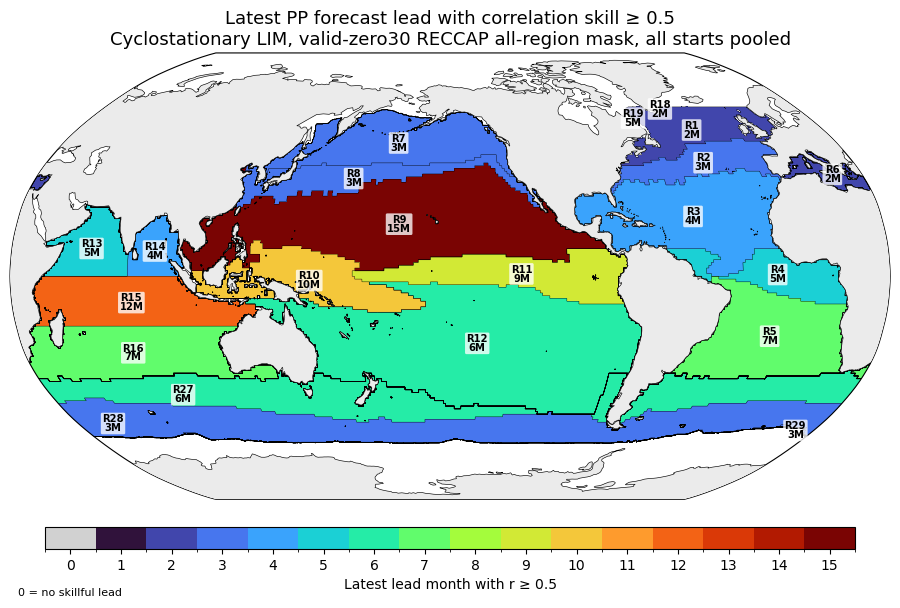

In [6]:
# ============================================================
# Map latest skillful lead by valid-zero30 RECCAP region
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path


# ============================================================
# Files
# ============================================================

VALID_MASK_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/"
    "GlobColour_PP_grid_validity_RECCAP2_all_regions/"
    "valid_mask_zero30/"
    "RECCAP2_all_regions_valid_mask_zero30_on_PPgrid.nc"
)

# Skill file generated from new valid-zero30 LIM
SKILL_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill/"
    "Cyclostationary_LIM_PP_forecast_skill_24month_corr_threshold05_"
    "RECCAP2_all_regions_valid_zero30.nc"
)

MAX_LEAD = 24
THRESHOLD = 0.5

CENTRAL_LONGITUDE = 210
PLOT_STRIDE = 4

OUT_FIG = SKILL_FILE.parent / (
    "Map_latest_PP_skillful_lead_corr_ge_05_"
    "RECCAP2_all_regions_valid_zero30.png"
)


# ============================================================
# Helper functions
# ============================================================

def lon_to_180(lon):
    return ((lon + 180.0) % 360.0) - 180.0


def weighted_centroid(lon, lat, mask):
    """
    Area-weighted centroid using cosine latitude weights.
    Longitude centroid is circular.
    """
    lon2d, lat2d = np.meshgrid(lon, lat)

    weights = np.cos(np.deg2rad(lat2d))
    weights = np.where(mask, weights, 0.0)

    wsum = np.nansum(weights)

    if wsum <= 0:
        return np.nan, np.nan

    lon_rad = np.deg2rad(lon2d)

    x = np.nansum(weights * np.cos(lon_rad)) / wsum
    y = np.nansum(weights * np.sin(lon_rad)) / wsum

    lon_c = np.rad2deg(np.arctan2(y, x)) % 360.0
    lat_c = np.nansum(weights * lat2d) / wsum

    return lon_c, lat_c


def add_cyclic_manual(data, lon):
    """
    Add cyclic longitude column without requiring perfectly equal spacing.
    """
    lon = np.asarray(lon, dtype=np.float64)

    sort_idx = np.argsort(lon)
    lon_sorted = lon[sort_idx]
    data_sorted = data[:, sort_idx]

    dlon = float(np.nanmedian(np.diff(lon_sorted)))

    lon_cyc = np.concatenate([lon_sorted, [lon_sorted[-1] + dlon]])
    data_cyc = np.concatenate([data_sorted, data_sorted[:, :1]], axis=1)

    return data_cyc, lon_cyc


# ============================================================
# Load mask and skill
# ============================================================

ds_mask = xr.open_dataset(VALID_MASK_FILE)
ds_skill = xr.open_dataset(SKILL_FILE)

mask = ds_mask["valid_region_mask"]   # dims: latitude, longitude
latest = ds_skill["latest_lead_corr_ge_05"]

lat = ds_mask["latitude"].values.astype(float)
lon = ds_mask["longitude"].values.astype(float)

mask_values = mask.values.astype(np.int16)

print("Mask regions:", np.unique(mask_values[mask_values > 0]))
print("Skill regions:", latest["region"].values)


# ============================================================
# Build lead map on PP grid
# ============================================================

lead_map = np.full(mask_values.shape, np.nan, dtype=np.float32)

for reg in latest["region"].values:
    reg = int(reg)
    val = float(latest.sel(region=reg).values)

    lead_map[mask_values == reg] = val

# Mask outside retained valid regions
lead_map = np.where(mask_values > 0, lead_map, np.nan)


# ============================================================
# Coarsen for plotting only
# ============================================================

lat_plot = lat[::PLOT_STRIDE]
lon_plot = lon[::PLOT_STRIDE]

lead_plot = lead_map[::PLOT_STRIDE, ::PLOT_STRIDE]
mask_plot = mask_values[::PLOT_STRIDE, ::PLOT_STRIDE].astype(float)

lead_cyc, lon_cyc = add_cyclic_manual(lead_plot, lon_plot)
mask_cyc, _ = add_cyclic_manual(mask_plot, lon_plot)

# Region boundaries from valid mask
max_region_code = int(np.nanmax(mask_values))
boundary_levels = np.arange(0.5, max_region_code + 1.5, 1.0)


# ============================================================
# Discrete color scale for display
# ============================================================

# Skill was calculated up to MAX_LEAD=24,
# but the displayed map is capped at 15 months for better contrast.
DISPLAY_MAX_LEAD = 15

# Cap only for plotting.
# This does not change ds_skill or the actual latest_lead values.
lead_cyc_plot = lead_cyc.copy()
lead_cyc_plot = np.where(
    np.isfinite(lead_cyc_plot),
    np.minimum(lead_cyc_plot, DISPLAY_MAX_LEAD),
    np.nan,
)

# Integer bins: 0, 1, 2, ..., 15
bounds = np.arange(-0.5, DISPLAY_MAX_LEAD + 1.5, 1.0)

# 0 = no skillful lead: light gray
# 1-15 = high-contrast discrete colors
try:
    base = plt.get_cmap("turbo", DISPLAY_MAX_LEAD)
except ValueError:
    # Fallback for older matplotlib
    base = plt.get_cmap("plasma", DISPLAY_MAX_LEAD)

colors = [(0.82, 0.82, 0.82, 1.0)] + [base(i) for i in range(DISPLAY_MAX_LEAD)]

cmap = ListedColormap(colors)
cmap.set_bad((1, 1, 1, 0))

norm = BoundaryNorm(bounds, cmap.N)


# ============================================================
# Plot
# ============================================================

fig = plt.figure(figsize=(13.5, 6.2))

ax = plt.axes(
    projection=ccrs.Robinson(central_longitude=CENTRAL_LONGITUDE)
)

im = ax.pcolormesh(
    lon_cyc,
    lat_plot,
    lead_cyc_plot,
    cmap=cmap,
    norm=norm,
    shading="auto",
    transform=ccrs.PlateCarree(),
)

# Valid RECCAP region boundaries
ax.contour(
    lon_cyc,
    lat_plot,
    mask_cyc,
    levels=boundary_levels,
    colors="k",
    linewidths=0.30,
    transform=ccrs.PlateCarree(),
)

ax.add_feature(
    cfeature.LAND,
    facecolor="0.92",
    edgecolor="none",
    zorder=3,
)

ax.coastlines(linewidth=0.45, zorder=4)
ax.set_global()

ax.set_title(
    "Latest PP forecast lead with correlation skill ≥ 0.5\n"
    "Cyclostationary LIM, valid-zero30 RECCAP all-region mask, all starts pooled",
    fontsize=13,
)


# ============================================================
# Region labels: region code and latest lead
# ============================================================

for reg in latest["region"].values:
    reg = int(reg)

    region_mask = mask_values == reg

    if not np.any(region_mask):
        continue

    lon_c, lat_c = weighted_centroid(lon, lat, region_mask)

    if np.isfinite(lon_c) and np.isfinite(lat_c):
        val = int(latest.sel(region=reg).values)

        label_text = f"R{reg}\n{val}M"

        ax.text(
            lon_to_180(lon_c),
            lat_c,
            label_text,
            transform=ccrs.PlateCarree(),
            ha="center",
            va="center",
            fontsize=7.2,
            fontweight="bold",
            linespacing=0.85,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.78,
                boxstyle="round,pad=0.14",
            ),
            zorder=5,
        )


# ============================================================
# Colorbar
# ============================================================

fig.subplots_adjust(left=0.03, right=0.97, top=0.88, bottom=0.16)

cax = fig.add_axes([0.20, 0.08, 0.60, 0.035])

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    ticks=np.arange(0, DISPLAY_MAX_LEAD + 1, 1),
    boundaries=bounds,
)

cbar.set_label("Latest lead month with r ≥ 0.5")

cbar.ax.text(
    0,
    -1.8,
    "0 = no skillful lead",
    ha="center",
    va="top",
    transform=cbar.ax.get_xaxis_transform(),
    fontsize=8,
)

plt.show()

# plt.savefig(OUT_FIG, dpi=200, bbox_inches="tight")
# print(f"Saved figure: {OUT_FIG}")

Original mask regions: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19 27 28 29]
Plot mask regions: [ 1  2  3  4  5  7  8  9 10 11 12 13 14 15 16 27 28]
Original skill regions: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19 27 28 29]
Plotted skill regions: [ 1  2  3  4  5  7  8  9 10 11 12 13 14 15 16 27 28]


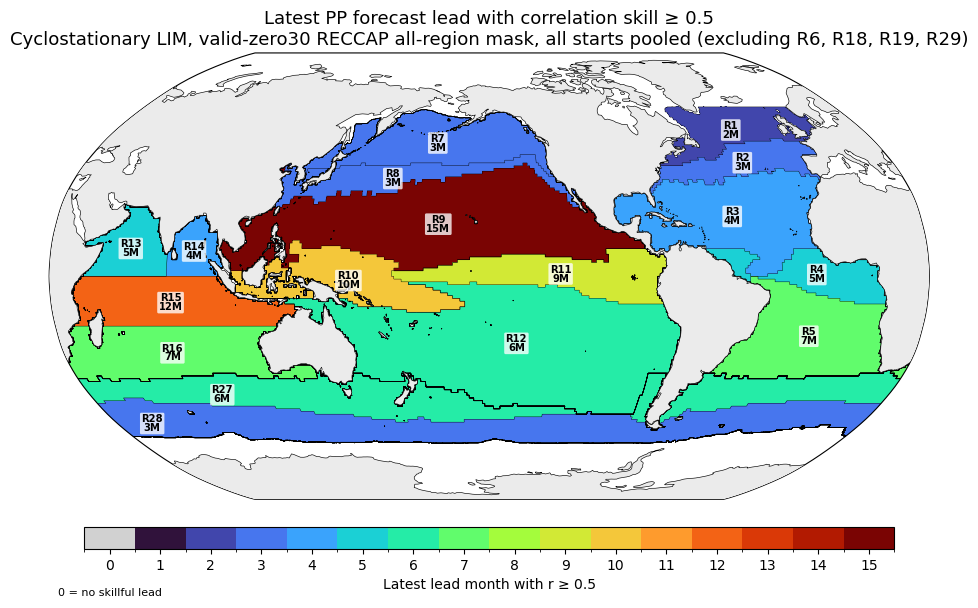

In [9]:
# ============================================================
# Map latest skillful lead by valid-zero30 RECCAP region
# excluding selected regions only for plotting
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path


# ============================================================
# Files
# ============================================================

VALID_MASK_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/"
    "GlobColour_PP_grid_validity_RECCAP2_all_regions/"
    "valid_mask_zero30/"
    "RECCAP2_all_regions_valid_mask_zero30_on_PPgrid.nc"
)

SKILL_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill/"
    "Cyclostationary_LIM_PP_forecast_skill_24month_corr_threshold05_"
    "RECCAP2_all_regions_valid_zero30.nc"
)

MAX_LEAD = 24
THRESHOLD = 0.5

CENTRAL_LONGITUDE = 210
PLOT_STRIDE = 4

# Regions to exclude only in this figure
EXCLUDE_PLOT_REGIONS = [6, 18, 19, 29]

DISPLAY_MAX_LEAD = 15

OUT_FIG = SKILL_FILE.parent / (
    "Map_latest_PP_skillful_lead_corr_ge_05_"
    "RECCAP2_all_regions_valid_zero30_excluding_R6_R18_R19_R29.png"
)


# ============================================================
# Helper functions
# ============================================================

def lon_to_180(lon):
    return ((lon + 180.0) % 360.0) - 180.0


def weighted_centroid(lon, lat, mask):
    """
    Area-weighted centroid using cosine latitude weights.
    Longitude centroid is circular.
    """
    lon2d, lat2d = np.meshgrid(lon, lat)

    weights = np.cos(np.deg2rad(lat2d))
    weights = np.where(mask, weights, 0.0)

    wsum = np.nansum(weights)

    if wsum <= 0:
        return np.nan, np.nan

    lon_rad = np.deg2rad(lon2d)

    x = np.nansum(weights * np.cos(lon_rad)) / wsum
    y = np.nansum(weights * np.sin(lon_rad)) / wsum

    lon_c = np.rad2deg(np.arctan2(y, x)) % 360.0
    lat_c = np.nansum(weights * lat2d) / wsum

    return lon_c, lat_c


def add_cyclic_manual(data, lon):
    """
    Add cyclic longitude column without requiring perfectly equal spacing.
    """
    lon = np.asarray(lon, dtype=np.float64)

    sort_idx = np.argsort(lon)
    lon_sorted = lon[sort_idx]
    data_sorted = data[:, sort_idx]

    dlon = float(np.nanmedian(np.diff(lon_sorted)))

    lon_cyc = np.concatenate([lon_sorted, [lon_sorted[-1] + dlon]])
    data_cyc = np.concatenate([data_sorted, data_sorted[:, :1]], axis=1)

    return data_cyc, lon_cyc


# ============================================================
# Load mask and skill
# ============================================================

ds_mask = xr.open_dataset(VALID_MASK_FILE)
ds_skill = xr.open_dataset(SKILL_FILE)

mask = ds_mask["valid_region_mask"]   # dims: latitude, longitude
latest = ds_skill["latest_lead_corr_ge_05"]

lat = ds_mask["latitude"].values.astype(float)
lon = ds_mask["longitude"].values.astype(float)

mask_values = mask.values.astype(np.int16)

# Exclude only for plotting
mask_plot_full = mask_values.copy()
for reg_ex in EXCLUDE_PLOT_REGIONS:
    mask_plot_full[mask_plot_full == reg_ex] = 0

# Keep only non-excluded skill regions for labels and mapping
regions_to_plot = [
    int(reg) for reg in latest["region"].values
    if int(reg) not in EXCLUDE_PLOT_REGIONS
]

latest_plot = latest.sel(region=regions_to_plot)

print("Original mask regions:", np.unique(mask_values[mask_values > 0]))
print("Plot mask regions:", np.unique(mask_plot_full[mask_plot_full > 0]))
print("Original skill regions:", latest["region"].values)
print("Plotted skill regions:", latest_plot["region"].values)


# ============================================================
# Build lead map on PP grid
# ============================================================

lead_map = np.full(mask_values.shape, np.nan, dtype=np.float32)

for reg in latest_plot["region"].values:
    reg = int(reg)
    val = float(latest_plot.sel(region=reg).values)
    lead_map[mask_plot_full == reg] = val

# Outside retained regions -> NaN
lead_map = np.where(mask_plot_full > 0, lead_map, np.nan)


# ============================================================
# Coarsen for plotting only
# ============================================================

lat_plot = lat[::PLOT_STRIDE]
lon_plot = lon[::PLOT_STRIDE]

lead_plot = lead_map[::PLOT_STRIDE, ::PLOT_STRIDE]
mask_plot = mask_plot_full[::PLOT_STRIDE, ::PLOT_STRIDE].astype(float)

lead_cyc, lon_cyc = add_cyclic_manual(lead_plot, lon_plot)
mask_cyc, _ = add_cyclic_manual(mask_plot, lon_plot)

# Boundary levels based on remaining plotted regions
remaining_regions = np.unique(mask_plot_full[mask_plot_full > 0])
boundary_levels = np.arange(0.5, int(np.nanmax(remaining_regions)) + 1.5, 1.0)


# ============================================================
# Discrete color scale for display
# ============================================================

lead_cyc_plot = lead_cyc.copy()
lead_cyc_plot = np.where(
    np.isfinite(lead_cyc_plot),
    np.minimum(lead_cyc_plot, DISPLAY_MAX_LEAD),
    np.nan,
)

bounds = np.arange(-0.5, DISPLAY_MAX_LEAD + 1.5, 1.0)

try:
    base = plt.get_cmap("turbo", DISPLAY_MAX_LEAD)
except ValueError:
    base = plt.get_cmap("plasma", DISPLAY_MAX_LEAD)

colors = [(0.82, 0.82, 0.82, 1.0)] + [base(i) for i in range(DISPLAY_MAX_LEAD)]

cmap = ListedColormap(colors)
cmap.set_bad((1, 1, 1, 0))

norm = BoundaryNorm(bounds, cmap.N)


# ============================================================
# Plot
# ============================================================

fig = plt.figure(figsize=(13.5, 6.2))

ax = plt.axes(
    projection=ccrs.Robinson(central_longitude=CENTRAL_LONGITUDE)
)

im = ax.pcolormesh(
    lon_cyc,
    lat_plot,
    lead_cyc_plot,
    cmap=cmap,
    norm=norm,
    shading="auto",
    transform=ccrs.PlateCarree(),
)

# Valid RECCAP region boundaries after exclusion
ax.contour(
    lon_cyc,
    lat_plot,
    mask_cyc,
    levels=boundary_levels,
    colors="k",
    linewidths=0.30,
    transform=ccrs.PlateCarree(),
)

ax.add_feature(
    cfeature.LAND,
    facecolor="0.92",
    edgecolor="none",
    zorder=3,
)

ax.coastlines(linewidth=0.45, zorder=4)
ax.set_global()

ax.set_title(
    "Latest PP forecast lead with correlation skill ≥ 0.5\n"
    "Cyclostationary LIM, valid-zero30 RECCAP all-region mask, "
    "all starts pooled (excluding R6, R18, R19, R29)",
    fontsize=13,
)


# ============================================================
# Region labels: region code and latest lead
# ============================================================

for reg in latest_plot["region"].values:
    reg = int(reg)

    region_mask = mask_plot_full == reg

    if not np.any(region_mask):
        continue

    lon_c, lat_c = weighted_centroid(lon, lat, region_mask)

    if np.isfinite(lon_c) and np.isfinite(lat_c):
        val = int(latest_plot.sel(region=reg).values)

        label_text = f"R{reg}\n{val}M"

        ax.text(
            lon_to_180(lon_c),
            lat_c,
            label_text,
            transform=ccrs.PlateCarree(),
            ha="center",
            va="center",
            fontsize=7.2,
            fontweight="bold",
            linespacing=0.85,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.78,
                boxstyle="round,pad=0.14",
            ),
            zorder=5,
        )


# ============================================================
# Colorbar
# ============================================================

fig.subplots_adjust(left=0.03, right=0.97, top=0.88, bottom=0.16)

cax = fig.add_axes([0.20, 0.08, 0.60, 0.035])

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    ticks=np.arange(0, DISPLAY_MAX_LEAD + 1, 1),
    boundaries=bounds,
)

cbar.set_label("Latest lead month with r ≥ 0.5")

cbar.ax.text(
    0,
    -1.8,
    "0 = no skillful lead",
    ha="center",
    va="top",
    transform=cbar.ax.get_xaxis_transform(),
    fontsize=8,
)

plt.show()

# plt.savefig(OUT_FIG, dpi=200, bbox_inches="tight")
# print(f"Saved figure: {OUT_FIG}")

Common period:
1998-01-15T00:00:00.000000000 to 2025-12-15T00:00:00.000000000
ntime: 336
nregion: 17
predictors: ['TENSO', 'WWV', 'NPMM', 'SPMM', 'IOB', 'IOD', 'SIOD', 'TNA', 'ATL3', 'SASD']

Regions used:
[ 1  2  3  4  5  7  8  9 10 11 12 13 14 15 16 27 28]
[01/17] regression for region 1
[02/17] regression for region 2
[03/17] regression for region 3
[04/17] regression for region 4
[05/17] regression for region 5
[06/17] regression for region 7
[07/17] regression for region 8
[08/17] regression for region 9
[09/17] regression for region 10
[10/17] regression for region 11
[11/17] regression for region 12
[12/17] regression for region 13
[13/17] regression for region 14
[14/17] regression for region 15
[15/17] regression for region 16
[16/17] regression for region 27
[17/17] regression for region 28

Regression summary:
 region       region_name  explained_percent  adjusted_explained_percent  cv_explained_percent      snr   cv_snr
      1           NA SPSS           9.462849          

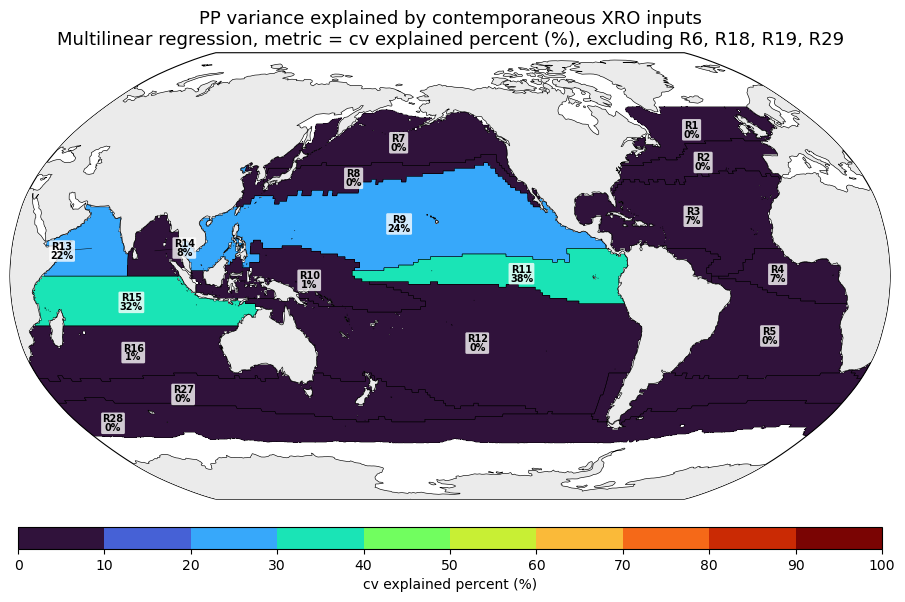

Saved figure: /nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/regression/Map_MLR_XRO_inputs_PP_explained_percent_valid_zero30.png


<Figure size 640x480 with 0 Axes>

In [10]:
# ============================================================
# Multilinear regression:
# How much regional PP variance is explained by XRO inputs?
# ============================================================

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import date
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# Files
# ============================================================

BASE_DIR = Path("/nird/datalake/NS11071K/users/yongyub/Observation")

XRO_FILE = (
    BASE_DIR / "ORAS5" / "XRO_input" /
    "ORAS5_XRO_input_indices_1998_2025_component_anom_then_detrend_deg1.nc"
)

PP_FILE = (
    BASE_DIR / "GlobColour" /
    "RECCAP2_all_regions_valid_zero30_region_mean_PP" /
    "GlobColour_PP_RECCAP2_all_regions_valid_zero30_area_mean_1998_2025.nc"
)

VALID_MASK_FILE = (
    BASE_DIR / "GlobColour" /
    "GlobColour_PP_grid_validity_RECCAP2_all_regions" /
    "valid_mask_zero30" /
    "RECCAP2_all_regions_valid_mask_zero30_on_PPgrid.nc"
)

OUT_DIR = Path("/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/regression")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_NC = OUT_DIR / "MLR_XRO_inputs_explain_GlobColour_PP_RECCAP2_valid_zero30_1998_2025.nc"
OUT_CSV = OUT_DIR / "MLR_XRO_inputs_explain_GlobColour_PP_RECCAP2_valid_zero30_1998_2025.csv"
OUT_FIG = OUT_DIR / "Map_MLR_XRO_inputs_PP_explained_percent_valid_zero30.png"


# ============================================================
# Settings
# ============================================================

XRO_VAR = "xro_input_standardized"

# Main PP variable:
#   "PP"            = zero-filled PP within valid-zero30 mask
#   "PP_valid_only" = valid-only sensitivity
PP_VAR = "PP"

REF_START = "1998-01-01"
REF_END   = "2025-12-31"

PP_TREND_DEGREE = 1

PREDICTOR_MODES = [
    "TENSO",
    "WWV",
    "NPMM",
    "SPMM",
    "IOB",
    "IOD",
    "SIOD",
    "TNA",
    "ATL3",
    "SASD",
]

# Exclude these regions from regression and plots
EXCLUDE_REGIONS = [6, 18, 19, 29]

# Map options
CENTRAL_LONGITUDE = 210
PLOT_STRIDE = 4

# Plot one of:
#   "explained_percent"
#   "adjusted_explained_percent"
#   "cv_explained_percent"
#   "snr"
#   "cv_snr"
PLOT_METRIC = "cv_explained_percent"

PLOT_MAX_PERCENT = 100.0
PLOT_STEP_PERCENT = 10.0

SHOW_LABELS = True
REGION_LABEL_OFFSETS = {
    13: (-12, -1),
    14: ( 12,  1),
}


# ============================================================
# Helper functions
# ============================================================

def decode_str_array(values):
    out = []

    for v in values:
        if isinstance(v, bytes):
            out.append(v.decode("utf-8"))
        else:
            arr = np.asarray(v)
            if arr.shape == ():
                item = arr.item()
                if isinstance(item, bytes):
                    out.append(item.decode("utf-8"))
                else:
                    out.append(str(item))
            else:
                out.append(str(v))

    return np.array(out, dtype=object)


def remove_monthly_climatology(x, ref_start, ref_end):
    x_ref = x.sel(time=slice(ref_start, ref_end))
    clim = x_ref.groupby("time.month").mean("time", skipna=True)
    anom = x.groupby("time.month") - clim
    return anom, clim


def polynomial_detrend_by_dim(x, feature_dim, ref_start, ref_end, degree=1):
    x_fit = x.sel(time=slice(ref_start, ref_end))

    time_all = pd.to_datetime(x["time"].values)
    time_fit = pd.to_datetime(x_fit["time"].values)

    t0 = time_fit[0]

    t_all = ((time_all - t0) / np.timedelta64(1, "D")) / 365.25
    t_fit = ((time_fit - t0) / np.timedelta64(1, "D")) / 365.25

    out = xr.full_like(x, np.nan)
    trend = xr.full_like(x, np.nan)

    coeffs = []

    for val in x[feature_dim].values:
        y_fit = x_fit.sel({feature_dim: val}).values.astype(float)
        ok = np.isfinite(y_fit)

        if ok.sum() < degree + 2:
            coef = np.full(degree + 1, np.nan)
            coeffs.append(coef)
            continue

        coef = np.polyfit(t_fit[ok], y_fit[ok], deg=degree)
        tr = np.polyval(coef, t_all)

        y_all = x.sel({feature_dim: val}).values.astype(float)

        out.loc[{feature_dim: val}] = y_all - tr
        trend.loc[{feature_dim: val}] = tr

        coeffs.append(coef)

    coeff_da = xr.DataArray(
        np.asarray(coeffs),
        dims=(feature_dim, "poly_coeff"),
        coords={
            feature_dim: x[feature_dim].values,
            "poly_coeff": np.arange(degree + 1),
        },
        name="trend_coefficients",
    )

    return out, trend, coeff_da


def standardize_by_dim(x, feature_dim, ref_start, ref_end):
    x_ref = x.sel(time=slice(ref_start, ref_end))

    mean = x_ref.mean("time", skipna=True)
    std = x_ref.std("time", skipna=True)

    std = xr.where(std > 0, std, np.nan)

    z = (x - mean) / std

    return z, mean, std


def r2_to_snr(r2):
    if not np.isfinite(r2):
        return np.nan

    if r2 <= 0:
        return 0.0

    if r2 >= 1:
        return np.inf

    return r2 / (1.0 - r2)


def fit_ols_metrics(y, X):
    """
    Fit y = b0 + X b.

    Returns:
        beta, intercept, yhat, r2, adj_r2, snr, n
    """
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)

    ok = np.isfinite(y) & np.isfinite(X).all(axis=1)

    y0 = y[ok]
    X0 = X[ok, :]

    n = len(y0)
    p = X0.shape[1]

    beta = np.full(p, np.nan)
    intercept = np.nan
    yhat_full = np.full_like(y, np.nan, dtype=float)

    if n <= p + 2:
        return beta, intercept, yhat_full, np.nan, np.nan, np.nan, n

    Xd = np.column_stack([np.ones(n), X0])

    coef, _, _, _ = np.linalg.lstsq(Xd, y0, rcond=None)

    intercept = coef[0]
    beta = coef[1:]

    yhat = Xd @ coef
    resid = y0 - yhat

    sst = np.sum((y0 - np.mean(y0)) ** 2)
    sse = np.sum(resid ** 2)

    if sst <= 0:
        r2 = np.nan
        adj_r2 = np.nan
        snr = np.nan
    else:
        r2 = 1.0 - sse / sst
        adj_r2 = 1.0 - (1.0 - r2) * (n - 1) / max(n - p - 1, 1)
        snr = r2_to_snr(r2)

    yhat_full[ok] = yhat

    return beta, intercept, yhat_full, r2, adj_r2, snr, n


def leave_one_year_out_metrics(y, X, times):
    """
    Leave-one-year-out cross-validated R2.
    """
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)

    years = pd.to_datetime(times).year.values
    unique_years = np.unique(years)

    ok_all = np.isfinite(y) & np.isfinite(X).all(axis=1)

    yhat_cv = np.full_like(y, np.nan, dtype=float)

    p = X.shape[1]

    for yy in unique_years:
        train = ok_all & (years != yy)
        test = ok_all & (years == yy)

        if train.sum() <= p + 2:
            continue

        X_train = X[train, :]
        y_train = y[train]

        X_test = X[test, :]

        Xd_train = np.column_stack([np.ones(train.sum()), X_train])
        Xd_test = np.column_stack([np.ones(test.sum()), X_test])

        coef, _, _, _ = np.linalg.lstsq(Xd_train, y_train, rcond=None)

        yhat_cv[test] = Xd_test @ coef

    ok = np.isfinite(y) & np.isfinite(yhat_cv)

    n_cv = int(ok.sum())

    if n_cv <= p + 2:
        return yhat_cv, np.nan, np.nan, n_cv

    y0 = y[ok]
    yhat0 = yhat_cv[ok]

    sst = np.sum((y0 - np.mean(y0)) ** 2)
    sse = np.sum((y0 - yhat0) ** 2)

    if sst <= 0:
        cv_r2 = np.nan
    else:
        cv_r2 = 1.0 - sse / sst

    cv_snr = r2_to_snr(cv_r2)

    return yhat_cv, cv_r2, cv_snr, n_cv


def lon_to_180(lon):
    return ((lon + 180.0) % 360.0) - 180.0


def weighted_centroid(lon, lat, mask):
    lon2d, lat2d = np.meshgrid(lon, lat)

    weights = np.cos(np.deg2rad(lat2d))
    weights = np.where(mask, weights, 0.0)

    wsum = np.nansum(weights)

    if wsum <= 0:
        return np.nan, np.nan

    lon_rad = np.deg2rad(lon2d)

    x = np.nansum(weights * np.cos(lon_rad)) / wsum
    y = np.nansum(weights * np.sin(lon_rad)) / wsum

    lon_c = np.rad2deg(np.arctan2(y, x)) % 360.0
    lat_c = np.nansum(weights * lat2d) / wsum

    return lon_c, lat_c


def add_cyclic_manual(data, lon):
    lon = np.asarray(lon, dtype=np.float64)

    sort_idx = np.argsort(lon)
    lon_sorted = lon[sort_idx]
    data_sorted = data[:, sort_idx]

    dlon = float(np.nanmedian(np.diff(lon_sorted)))

    lon_cyc = np.concatenate([lon_sorted, [lon_sorted[-1] + dlon]])
    data_cyc = np.concatenate([data_sorted, data_sorted[:, :1]], axis=1)

    return data_cyc, lon_cyc


# ============================================================
# Load data
# ============================================================

ds_xro = xr.open_dataset(XRO_FILE)
ds_pp = xr.open_dataset(PP_FILE)
ds_mask = xr.open_dataset(VALID_MASK_FILE)

if XRO_VAR not in ds_xro:
    raise KeyError(f"{XRO_VAR} not found in {XRO_FILE}")

if PP_VAR not in ds_pp:
    raise KeyError(f"{PP_VAR} not found in {PP_FILE}")

xro = ds_xro[XRO_VAR].sel(mode=PREDICTOR_MODES).sortby("time")
pp_raw = ds_pp[PP_VAR].sortby("time")

# Exclude selected regions from analysis
regions_keep = [
    int(r) for r in pp_raw["region"].values
    if int(r) not in EXCLUDE_REGIONS
]

pp_raw = pp_raw.sel(region=regions_keep)

# Align time
pp_raw, xro = xr.align(pp_raw, xro, join="inner")

print("Common period:")
print(str(pp_raw["time"].values[0]), "to", str(pp_raw["time"].values[-1]))
print("ntime:", pp_raw.sizes["time"])
print("nregion:", pp_raw.sizes["region"])
print("predictors:", list(xro["mode"].values))


# ============================================================
# Preprocess PP in XRO-like way
# ============================================================

pp_anom, pp_clim = remove_monthly_climatology(
    pp_raw,
    REF_START,
    REF_END,
)

pp_detrended, pp_trend, pp_trend_coeff = polynomial_detrend_by_dim(
    pp_anom,
    feature_dim="region",
    ref_start=REF_START,
    ref_end=REF_END,
    degree=PP_TREND_DEGREE,
)

pp_std, pp_mean, pp_stddev = standardize_by_dim(
    pp_detrended,
    feature_dim="region",
    ref_start=REF_START,
    ref_end=REF_END,
)

# Drop regions that became all-NaN
finite_region = np.isfinite(pp_std).any("time")
pp_std = pp_std.sel(region=pp_std["region"].where(finite_region, drop=True))

regions = pp_std["region"].values.astype(np.int16)
times = pp_std["time"].values
predictors = xro["mode"].values.astype(str)

n_region = len(regions)
n_pred = len(predictors)
n_time = len(times)

print("\nRegions used:")
print(regions)


# ============================================================
# Regression by region
# ============================================================

X = xro.transpose("time", "mode").values.astype(float)

beta_all = np.full((n_region, n_pred), np.nan, dtype=np.float64)
intercept_all = np.full(n_region, np.nan, dtype=np.float64)

r2_all = np.full(n_region, np.nan, dtype=np.float64)
adj_r2_all = np.full(n_region, np.nan, dtype=np.float64)
snr_all = np.full(n_region, np.nan, dtype=np.float64)

cv_r2_all = np.full(n_region, np.nan, dtype=np.float64)
cv_snr_all = np.full(n_region, np.nan, dtype=np.float64)

n_samples_all = np.zeros(n_region, dtype=np.int16)
n_cv_samples_all = np.zeros(n_region, dtype=np.int16)

pp_hat = np.full((n_time, n_region), np.nan, dtype=np.float32)
pp_hat_cv = np.full((n_time, n_region), np.nan, dtype=np.float32)

for ir, reg in enumerate(regions):
    print(f"[{ir+1:02d}/{n_region:02d}] regression for region {int(reg)}")

    y = pp_std.sel(region=reg).values.astype(float)

    beta, intercept, yhat, r2, adj_r2, snr, n = fit_ols_metrics(y, X)

    yhat_cv, cv_r2, cv_snr, n_cv = leave_one_year_out_metrics(
        y,
        X,
        times,
    )

    beta_all[ir, :] = beta
    intercept_all[ir] = intercept

    r2_all[ir] = r2
    adj_r2_all[ir] = adj_r2
    snr_all[ir] = snr

    cv_r2_all[ir] = cv_r2
    cv_snr_all[ir] = cv_snr

    n_samples_all[ir] = n
    n_cv_samples_all[ir] = n_cv

    pp_hat[:, ir] = yhat.astype(np.float32)
    pp_hat_cv[:, ir] = yhat_cv.astype(np.float32)


explained_percent = 100.0 * r2_all
adjusted_explained_percent = 100.0 * adj_r2_all
cv_explained_percent = 100.0 * cv_r2_all

# Negative CV R2 means worse than climatological mean.
# For plotting percent explained, set negative values to 0.
cv_explained_percent_plot = np.where(
    np.isfinite(cv_explained_percent),
    np.maximum(cv_explained_percent, 0.0),
    np.nan,
)


# ============================================================
# Region metadata
# ============================================================

if "region_name" in ds_pp:
    region_name = decode_str_array(ds_pp["region_name"].sel(region=regions).values)
else:
    region_name = np.array([f"region {int(r)}" for r in regions], dtype=object)

if "basin" in ds_pp:
    basin = decode_str_array(ds_pp["basin"].sel(region=regions).values)
else:
    basin = np.array([""] * n_region, dtype=object)

if "original_region_id" in ds_pp:
    original_region_id = ds_pp["original_region_id"].sel(region=regions).values.astype(np.int16)
else:
    original_region_id = np.full(n_region, -999, dtype=np.int16)


# ============================================================
# Save table
# ============================================================

summary_df = pd.DataFrame(
    {
        "region": regions.astype(int),
        "basin": basin,
        "original_region_id": original_region_id.astype(int),
        "region_name": region_name,
        "n_samples": n_samples_all.astype(int),
        "r2": r2_all,
        "explained_percent": explained_percent,
        "adjusted_r2": adj_r2_all,
        "adjusted_explained_percent": adjusted_explained_percent,
        "snr": snr_all,
        "cv_r2": cv_r2_all,
        "cv_explained_percent": cv_explained_percent,
        "cv_snr": cv_snr_all,
        "n_cv_samples": n_cv_samples_all.astype(int),
    }
)

summary_df.to_csv(OUT_CSV, index=False)

print("\nRegression summary:")
print(
    summary_df[
        [
            "region",
            "region_name",
            "explained_percent",
            "adjusted_explained_percent",
            "cv_explained_percent",
            "snr",
            "cv_snr",
        ]
    ].to_string(index=False)
)

print(f"\nSaved CSV: {OUT_CSV}")


# ============================================================
# Save NetCDF
# ============================================================

out_ds = xr.Dataset(
    data_vars={
        "beta": (
            ("region", "predictor"),
            beta_all.astype(np.float32),
            {
                "long_name": "Standardized multilinear regression coefficient",
                "description": "PP_std = intercept + sum beta_i * XRO_i",
            },
        ),
        "intercept": (
            ("region",),
            intercept_all.astype(np.float32),
            {"long_name": "Regression intercept"},
        ),
        "r2": (
            ("region",),
            r2_all.astype(np.float32),
            {"long_name": "In-sample coefficient of determination"},
        ),
        "explained_percent": (
            ("region",),
            explained_percent.astype(np.float32),
            {
                "long_name": "In-sample PP variance explained by XRO inputs",
                "units": "%",
            },
        ),
        "adjusted_r2": (
            ("region",),
            adj_r2_all.astype(np.float32),
            {"long_name": "Adjusted in-sample R2"},
        ),
        "adjusted_explained_percent": (
            ("region",),
            adjusted_explained_percent.astype(np.float32),
            {
                "long_name": "Adjusted in-sample PP variance explained by XRO inputs",
                "units": "%",
            },
        ),
        "snr": (
            ("region",),
            snr_all.astype(np.float32),
            {
                "long_name": "Signal-to-noise ratio from in-sample R2",
                "description": "snr = R2 / (1 - R2)",
            },
        ),
        "cv_r2": (
            ("region",),
            cv_r2_all.astype(np.float32),
            {
                "long_name": "Leave-one-year-out cross-validated R2",
                "description": "Can be negative if prediction is worse than the mean.",
            },
        ),
        "cv_explained_percent": (
            ("region",),
            cv_explained_percent.astype(np.float32),
            {
                "long_name": "Leave-one-year-out cross-validated explained variance",
                "units": "%",
            },
        ),
        "cv_snr": (
            ("region",),
            cv_snr_all.astype(np.float32),
            {
                "long_name": "Signal-to-noise ratio from cross-validated R2",
                "description": "snr = R2 / (1 - R2), set to 0 when R2 <= 0.",
            },
        ),
        "n_samples": (
            ("region",),
            n_samples_all.astype(np.int16),
            {"long_name": "Number of samples used for in-sample regression"},
        ),
        "n_cv_samples": (
            ("region",),
            n_cv_samples_all.astype(np.int16),
            {"long_name": "Number of samples used for cross-validated scoring"},
        ),
        "PP_standardized": (
            ("time", "region"),
            pp_std.sel(region=regions).transpose("time", "region").values.astype(np.float32),
            {
                "long_name": "Preprocessed standardized PP",
                "description": "Monthly climatology removed, detrended, standardized by region.",
            },
        ),
        "PP_fitted": (
            ("time", "region"),
            pp_hat,
            {"long_name": "In-sample fitted standardized PP"},
        ),
        "PP_fitted_cv": (
            ("time", "region"),
            pp_hat_cv,
            {"long_name": "Leave-one-year-out fitted standardized PP"},
        ),
        "region_name": (
            ("region",),
            region_name.astype(object),
            {"long_name": "RECCAP2 region name"},
        ),
        "basin": (
            ("region",),
            basin.astype(object),
            {"long_name": "Original RECCAP2 basin"},
        ),
        "original_region_id": (
            ("region",),
            original_region_id.astype(np.int16),
            {"long_name": "Original RECCAP2 region ID"},
        ),
    },
    coords={
        "region": regions.astype(np.int16),
        "predictor": predictors.astype(object),
        "time": times,
    },
    attrs={
        "title": "Multilinear regression of regional PP onto XRO inputs",
        "description": (
            "For each valid-zero30 RECCAP2 region, standardized regional PP is regressed "
            "onto contemporaneous standardized XRO input indices. PP is monthly-climatology-"
            "removed, linearly detrended, and standardized. XRO predictors are read from "
            f"{XRO_VAR}."
        ),
        "pp_file": str(PP_FILE),
        "pp_variable": PP_VAR,
        "xro_file": str(XRO_FILE),
        "xro_variable": XRO_VAR,
        "predictors": ", ".join(PREDICTOR_MODES),
        "excluded_regions": ", ".join([f"R{r}" for r in EXCLUDE_REGIONS]),
        "snr_definition": "snr = R2 / (1 - R2)",
        "created_by": "custom Python/xarray script",
        "date_created": date.today().isoformat(),
    },
)

encoding = {
    "beta": {"dtype": "float32", "_FillValue": np.float32(-999.0), "zlib": True, "complevel": 4},
    "intercept": {"dtype": "float32", "_FillValue": np.float32(-999.0)},
    "r2": {"dtype": "float32", "_FillValue": np.float32(-999.0)},
    "explained_percent": {"dtype": "float32", "_FillValue": np.float32(-999.0)},
    "adjusted_r2": {"dtype": "float32", "_FillValue": np.float32(-999.0)},
    "adjusted_explained_percent": {"dtype": "float32", "_FillValue": np.float32(-999.0)},
    "snr": {"dtype": "float32", "_FillValue": np.float32(-999.0)},
    "cv_r2": {"dtype": "float32", "_FillValue": np.float32(-999.0)},
    "cv_explained_percent": {"dtype": "float32", "_FillValue": np.float32(-999.0)},
    "cv_snr": {"dtype": "float32", "_FillValue": np.float32(-999.0)},
    "n_samples": {"dtype": "int16", "_FillValue": None},
    "n_cv_samples": {"dtype": "int16", "_FillValue": None},
    "PP_standardized": {"dtype": "float32", "_FillValue": np.float32(-999.0), "zlib": True, "complevel": 4},
    "PP_fitted": {"dtype": "float32", "_FillValue": np.float32(-999.0), "zlib": True, "complevel": 4},
    "PP_fitted_cv": {"dtype": "float32", "_FillValue": np.float32(-999.0), "zlib": True, "complevel": 4},
    "original_region_id": {"dtype": "int16", "_FillValue": None},
    "region": {"dtype": "int16", "_FillValue": None},
    "time": {
        "dtype": "float64",
        "units": "days since 1900-01-01",
        "calendar": "gregorian",
    },
}

if OUT_NC.exists():
    OUT_NC.unlink()

out_ds.to_netcdf(OUT_NC, encoding=encoding, engine="netcdf4")

print(f"Saved NetCDF: {OUT_NC}")


# ============================================================
# Map selected metric
# ============================================================

if PLOT_METRIC not in out_ds:
    raise KeyError(f"{PLOT_METRIC} not found in out_ds.")

metric = out_ds[PLOT_METRIC]

mask_values = ds_mask["valid_region_mask"].values.astype(np.int16)

lat = ds_mask["latitude"].values.astype(float)
lon = ds_mask["longitude"].values.astype(float)

# Exclude regions in plot mask
plot_mask = mask_values.copy()

for rr in EXCLUDE_REGIONS:
    plot_mask[plot_mask == rr] = 0

metric_map = np.full(plot_mask.shape, np.nan, dtype=np.float32)

for reg in metric["region"].values:
    reg = int(reg)

    if reg in EXCLUDE_REGIONS:
        continue

    val = float(metric.sel(region=reg).values)

    # For percent maps, negative CV explained variance is plotted as 0.
    if "percent" in PLOT_METRIC and np.isfinite(val):
        val = max(val, 0.0)

    metric_map[plot_mask == reg] = val

metric_map = np.where(plot_mask > 0, metric_map, np.nan)

lat_plot = lat[::PLOT_STRIDE]
lon_plot = lon[::PLOT_STRIDE]

metric_plot = metric_map[::PLOT_STRIDE, ::PLOT_STRIDE]
mask_plot = plot_mask[::PLOT_STRIDE, ::PLOT_STRIDE].astype(float)

metric_cyc, lon_cyc = add_cyclic_manual(metric_plot, lon_plot)
mask_cyc, _ = add_cyclic_manual(mask_plot, lon_plot)

# Cap percent only for display
if "percent" in PLOT_METRIC:
    metric_cyc = np.where(
        np.isfinite(metric_cyc),
        np.minimum(metric_cyc, PLOT_MAX_PERCENT),
        np.nan,
    )

    bounds = np.arange(
        0.0,
        PLOT_MAX_PERCENT + PLOT_STEP_PERCENT,
        PLOT_STEP_PERCENT,
    )

    cmap = plt.get_cmap("turbo", len(bounds) - 1)
    cmap.set_bad((1, 1, 1, 0))
    norm = BoundaryNorm(bounds, cmap.N)
    cbar_ticks = bounds

else:
    # SNR map
    PLOT_MAX_SNR = 2.0
    PLOT_STEP_SNR = 0.2

    metric_cyc = np.where(
        np.isfinite(metric_cyc),
        np.minimum(metric_cyc, PLOT_MAX_SNR),
        np.nan,
    )

    bounds = np.arange(0.0, PLOT_MAX_SNR + PLOT_STEP_SNR, PLOT_STEP_SNR)

    cmap = plt.get_cmap("turbo", len(bounds) - 1)
    cmap.set_bad((1, 1, 1, 0))
    norm = BoundaryNorm(bounds, cmap.N)
    cbar_ticks = bounds


# ============================================================
# Draw map
# ============================================================

fig = plt.figure(figsize=(13.5, 6.2))

ax = plt.axes(
    projection=ccrs.Robinson(central_longitude=CENTRAL_LONGITUDE)
)

im = ax.pcolormesh(
    lon_cyc,
    lat_plot,
    metric_cyc,
    cmap=cmap,
    norm=norm,
    shading="auto",
    transform=ccrs.PlateCarree(),
)

# Draw region boundaries robustly
region_codes_plot = sorted([int(c) for c in np.unique(plot_mask) if c > 0])

for code in region_codes_plot:
    binary = (mask_plot == code).astype(float)
    binary_cyc, _ = add_cyclic_manual(binary, lon_plot)

    if np.nanmax(binary_cyc) <= 0:
        continue

    ax.contour(
        lon_cyc,
        lat_plot,
        binary_cyc,
        levels=[0.5],
        colors="k",
        linewidths=0.32,
        transform=ccrs.PlateCarree(),
        zorder=4,
    )

ax.add_feature(
    cfeature.LAND,
    facecolor="0.92",
    edgecolor="none",
    zorder=3,
)

ax.coastlines(linewidth=0.45, zorder=5)
ax.set_global()

if "percent" in PLOT_METRIC:
    metric_label = PLOT_METRIC.replace("_", " ") + " (%)"
else:
    metric_label = PLOT_METRIC.replace("_", " ")

ax.set_title(
    "PP variance explained by contemporaneous XRO inputs\n"
    f"Multilinear regression, metric = {metric_label}, excluding "
    + ", ".join([f"R{r}" for r in EXCLUDE_REGIONS]),
    fontsize=13,
)


# ============================================================
# Region labels
# ============================================================

if SHOW_LABELS:
    for reg in region_codes_plot:
        region_mask = plot_mask == reg

        if not np.any(region_mask):
            continue

        lon_c, lat_c = weighted_centroid(lon, lat, region_mask)

        if not (np.isfinite(lon_c) and np.isfinite(lat_c)):
            continue

        val = float(metric.sel(region=reg).values)

        if "percent" in PLOT_METRIC and np.isfinite(val):
            label_val = max(val, 0.0)
            label_text = f"R{reg}\n{label_val:.0f}%"
        else:
            label_text = f"R{reg}\n{val:.2f}"

        dlon, dlat = REGION_LABEL_OFFSETS.get(reg, (0.0, 0.0))

        x0 = lon_to_180(lon_c)
        y0 = lat_c

        x1 = lon_to_180(lon_c + dlon)
        y1 = lat_c + dlat

        if (dlon != 0.0) or (dlat != 0.0):
            ax.plot(
                [x0, x1],
                [y0, y1],
                transform=ccrs.PlateCarree(),
                color="k",
                linewidth=0.45,
                alpha=0.75,
                zorder=6,
            )

        ax.text(
            x1,
            y1,
            label_text,
            transform=ccrs.PlateCarree(),
            ha="center",
            va="center",
            fontsize=7.0,
            fontweight="bold",
            linespacing=0.85,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.78,
                boxstyle="round,pad=0.14",
            ),
            zorder=7,
        )


# ============================================================
# Colorbar
# ============================================================

fig.subplots_adjust(left=0.03, right=0.97, top=0.88, bottom=0.16)

cax = fig.add_axes([0.18, 0.08, 0.64, 0.035])

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    boundaries=bounds,
    ticks=cbar_ticks,
)

cbar.set_label(metric_label)

plt.show()

plt.savefig(OUT_FIG, dpi=250, bbox_inches="tight")
print(f"Saved figure: {OUT_FIG}")

<xarray.Dataset>
Dimensions:                                (region: 21, init_time: 336,
                                            lead: 24, init_month: 12)
Coordinates:
  * region                                 (region) int16 1 2 3 4 ... 27 28 29
  * init_time                              (init_time) datetime64[ns] 1998-01...
  * lead                                   (lead) int16 1 2 3 4 ... 21 22 23 24
  * init_month                             (init_month) int16 1 2 3 ... 10 11 12
Data variables: (12/15)
    PP_prediction                          (region, init_time, lead) float32 ...
    PP_correlation_skill                   (region, lead) float32 ...
    PP_correlation_skill_by_init_month     (region, init_month, lead) float32 ...
    n_pairs                                (region, lead) int16 ...
    n_pairs_by_init_month                  (region, init_month, lead) int16 ...
    latest_lead_corr_ge_05                 (region) int16 ...
    ...                                 

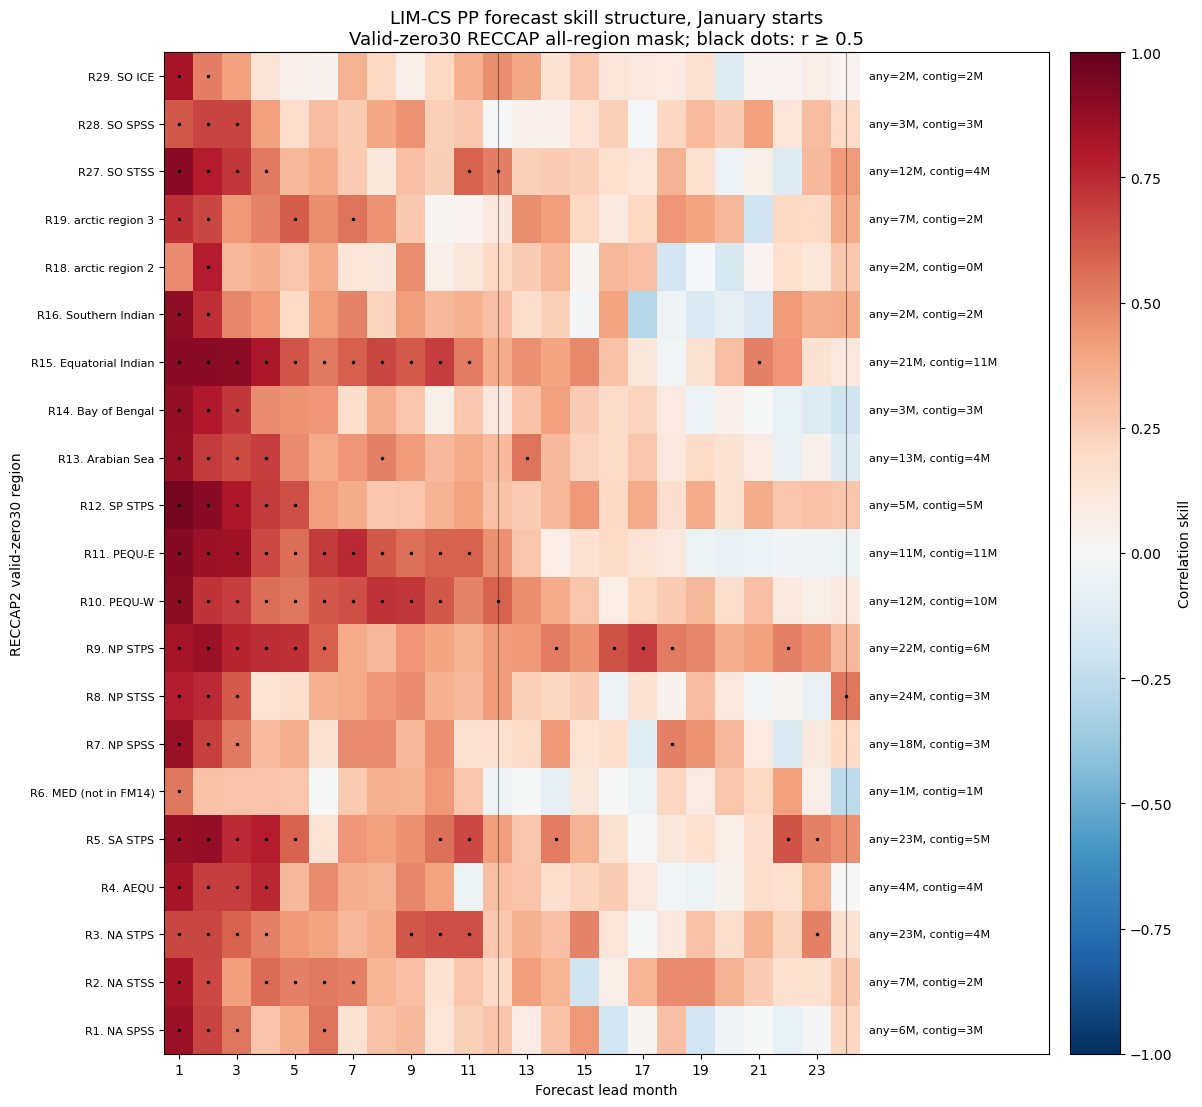

Saved: /nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill/LIM_CS_PP_skill_structure_valid_zero30_allregions_init_month_01_heatmap.png


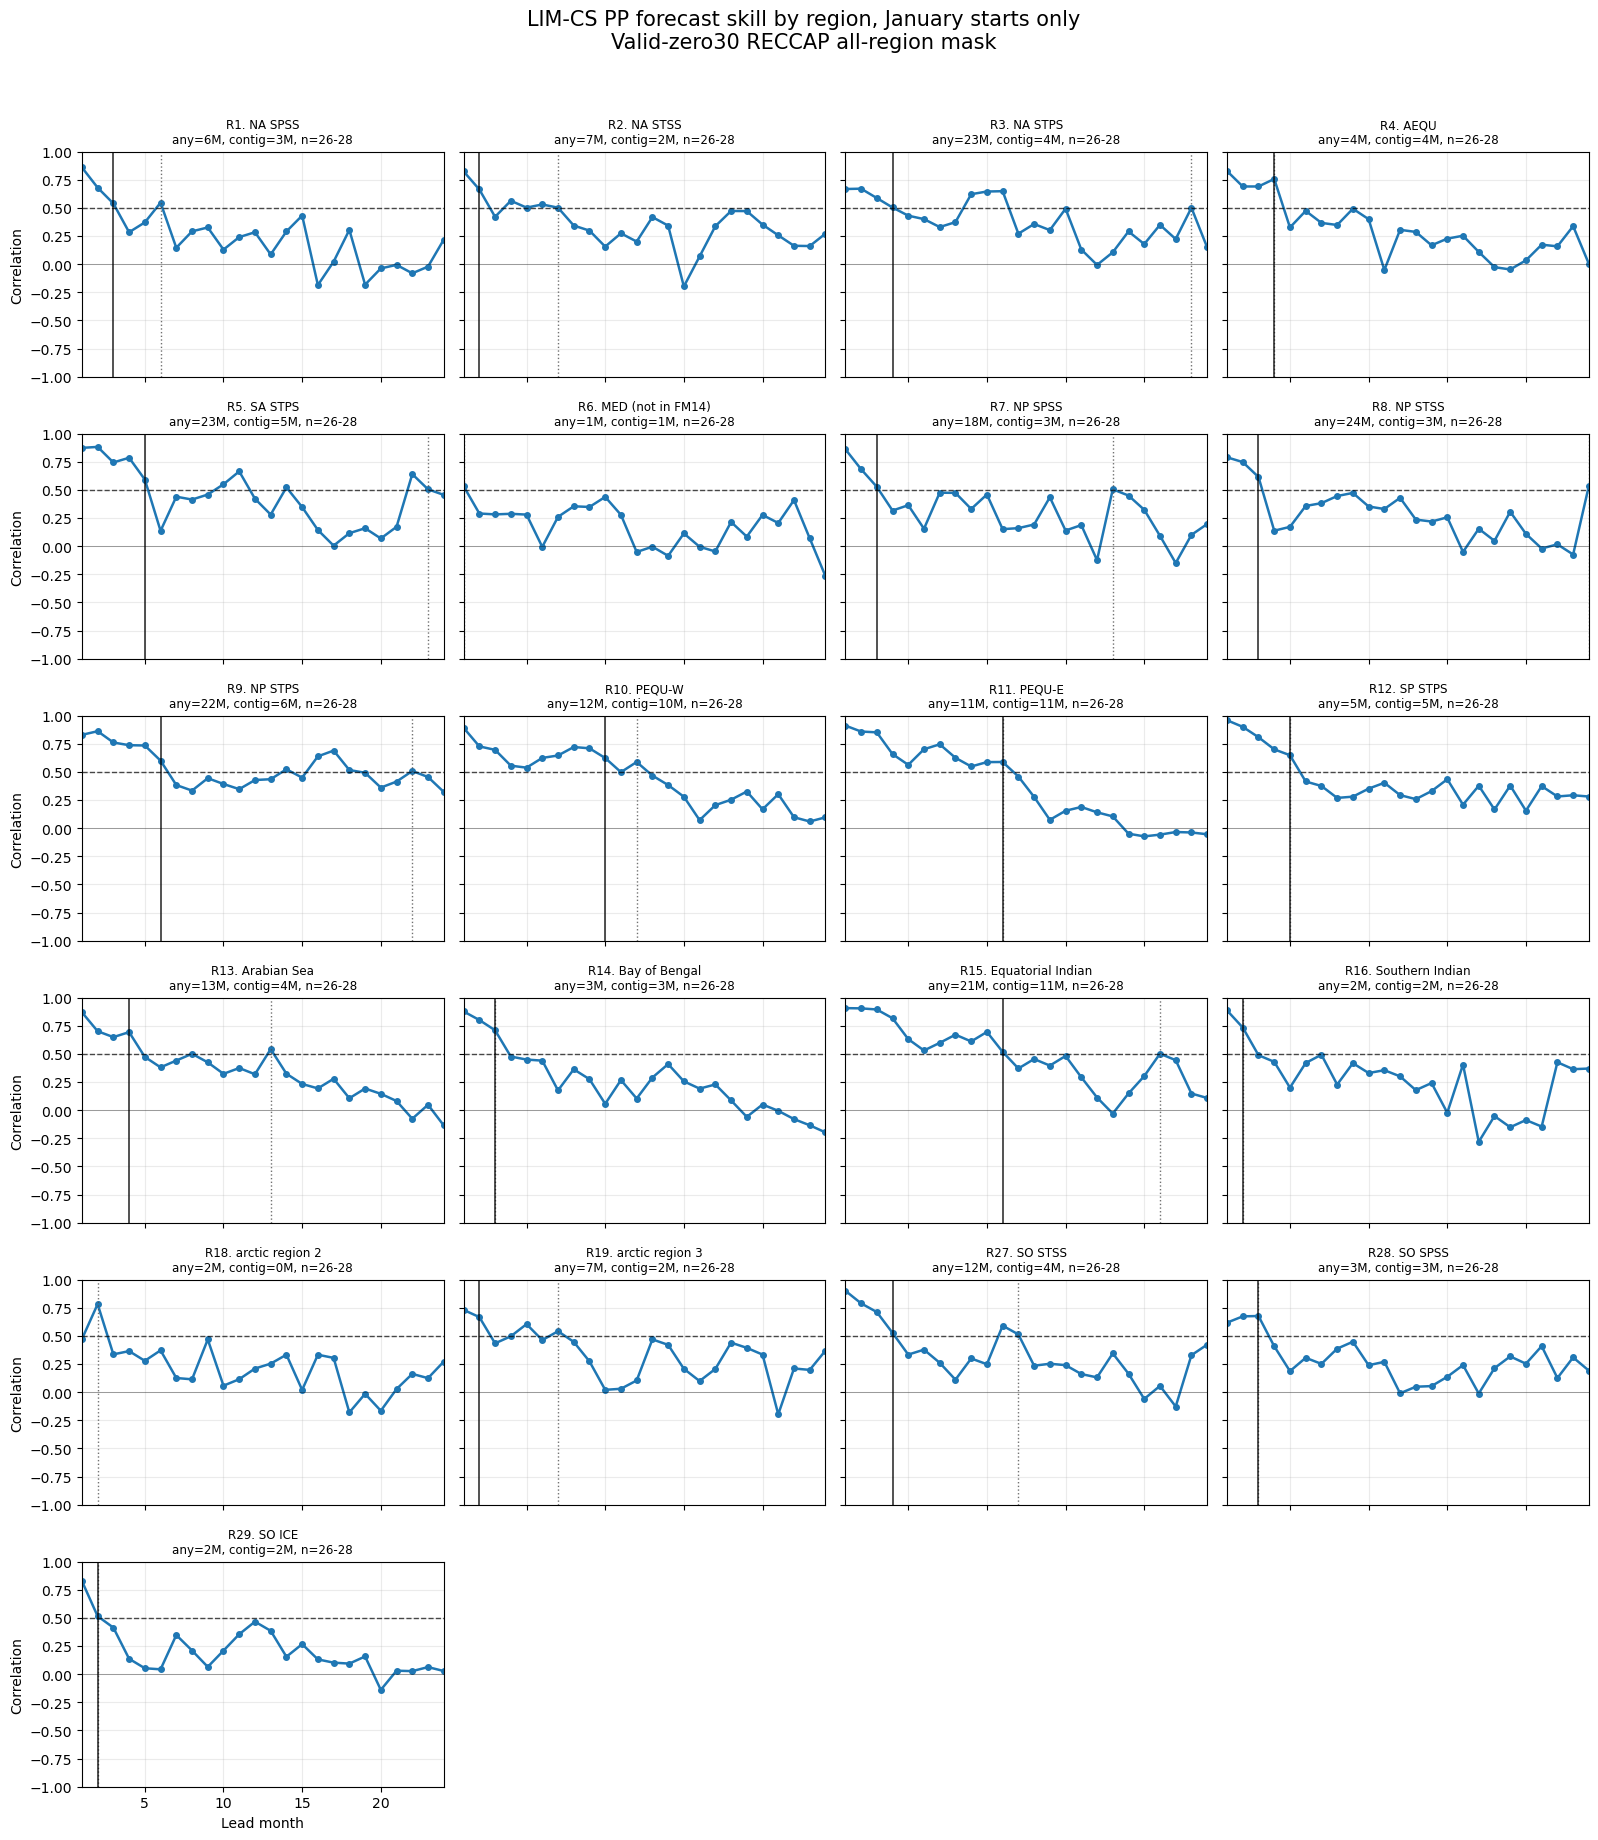

Saved: /nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill/LIM_CS_PP_skill_structure_valid_zero30_allregions_init_month_01_regional_lines.png


In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# Settings
# ============================================================

SKILL_FILE = (
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill/"
    "Cyclostationary_LIM_PP_forecast_skill_24month_corr_threshold05_"
    "RECCAP2_all_regions_valid_zero30.nc"
)

# If using the PP_valid_only sensitivity skill file, change SKILL_FILE accordingly.

OUT_DIR = Path("/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill")
OUT_DIR.mkdir(parents=True, exist_ok=True)

INIT_MONTH = 1
THRESHOLD = 0.5

FIG_HEATMAP = OUT_DIR / (
    f"LIM_CS_PP_skill_structure_valid_zero30_allregions_"
    f"init_month_{INIT_MONTH:02d}_heatmap.png"
)

FIG_LINES = OUT_DIR / (
    f"LIM_CS_PP_skill_structure_valid_zero30_allregions_"
    f"init_month_{INIT_MONTH:02d}_regional_lines.png"
)


# ============================================================
# Helper functions
# ============================================================

def latest_any_1d(r, threshold=0.5):
    """
    Latest lead where r >= threshold anywhere.
    This can be affected by late-lead isolated spikes.
    """
    r = np.asarray(r, dtype=float)
    good = np.where(np.isfinite(r) & (r >= threshold))[0]

    if len(good) == 0:
        return 0

    return int(good.max() + 1)


def latest_contiguous_1d(r, threshold=0.5):
    """
    Latest lead up to which r remains continuously >= threshold
    from lead 1 onward.
    """
    r = np.asarray(r, dtype=float)
    good = np.isfinite(r) & (r >= threshold)

    if len(good) == 0:
        return 0

    if not good[0]:
        return 0

    bad = np.where(~good)[0]

    if len(bad) == 0:
        return int(len(good))

    return int(bad[0])


def decode_str(v):
    """
    Decode netCDF string / byte-string scalar.
    """
    if isinstance(v, bytes):
        return v.decode("utf-8")

    arr = np.asarray(v)

    if arr.shape == ():
        item = arr.item()
        if isinstance(item, bytes):
            return item.decode("utf-8")
        return str(item)

    return str(v)


def get_region_label(ds, reg, short=True):
    """
    Region label for plotting.
    """
    reg = int(reg)

    if "region_name" in ds:
        try:
            name = decode_str(ds["region_name"].sel(region=reg).values)
        except Exception:
            name = f"region {reg}"
    else:
        name = f"region {reg}"

    if "basin" in ds:
        try:
            basin = decode_str(ds["basin"].sel(region=reg).values)
        except Exception:
            basin = ""
    else:
        basin = ""

    if "original_region_id" in ds:
        try:
            original_id = int(ds["original_region_id"].sel(region=reg).values)
        except Exception:
            original_id = -999
    else:
        original_id = -999

    if short:
        return f"R{reg}. {name}"

    if basin != "" and original_id > 0:
        return f"R{reg}. {basin}:{original_id} {name}"

    return f"R{reg}. {name}"


def month_name(m):
    names = [
        "January", "February", "March", "April",
        "May", "June", "July", "August",
        "September", "October", "November", "December",
    ]
    return names[int(m) - 1]


# ============================================================
# Load
# ============================================================

ds_skill = xr.open_dataset(SKILL_FILE)

r_sel = ds_skill["PP_correlation_skill_by_init_month"].sel(init_month=INIT_MONTH)
n_sel = ds_skill["n_pairs_by_init_month"].sel(init_month=INIT_MONTH)

regions = r_sel["region"].values.astype(np.int16)
leads = r_sel["lead"].values.astype(np.int16)

n_region = len(regions)
n_lead = len(leads)

print(ds_skill)
print("\nSelected skill array:")
print(r_sel)

print("\nRegions:")
for reg in regions:
    print(f"  {get_region_label(ds_skill, reg, short=False)}")


# ============================================================
# Latest lead diagnostics
# ============================================================

latest_any = xr.apply_ufunc(
    latest_any_1d,
    r_sel,
    input_core_dims=[["lead"]],
    output_core_dims=[[]],
    vectorize=True,
    kwargs={"threshold": THRESHOLD},
    output_dtypes=[np.int16],
)

latest_contig = xr.apply_ufunc(
    latest_contiguous_1d,
    r_sel,
    input_core_dims=[["lead"]],
    output_core_dims=[[]],
    vectorize=True,
    kwargs={"threshold": THRESHOLD},
    output_dtypes=[np.int16],
)

latest_any.name = "latest_any"
latest_contig.name = "latest_contiguous"

diag = xr.Dataset(
    {
        "latest_any": latest_any,
        "latest_contiguous": latest_contig,
        "n_pairs_min": n_sel.min("lead"),
        "n_pairs_max": n_sel.max("lead"),
    }
)

print(f"\n=== {month_name(INIT_MONTH)}-start latest lead diagnostics ===")
print(diag.to_dataframe())


# ============================================================
# 1. Heatmap: region index x lead
# ============================================================

fig, ax = plt.subplots(figsize=(12.5, 0.38 * n_region + 3.2))

# Use ordinal y positions to avoid gaps when some RECCAP region codes are missing.
y_edges = np.arange(n_region + 1)
x_edges = np.arange(leads[0] - 0.5, leads[-1] + 1.5, 1.0)

im = ax.pcolormesh(
    x_edges,
    y_edges,
    r_sel.values,
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
    shading="auto",
)

# Mark r >= threshold
rr = r_sel.values

for ireg, reg in enumerate(regions):
    y = ireg + 0.5

    for ilead, lead in enumerate(leads):
        if np.isfinite(rr[ireg, ilead]) and rr[ireg, ilead] >= THRESHOLD:
            ax.plot(
                lead,
                y,
                "k.",
                markersize=3,
            )

# Add latest-any and latest-contiguous labels
for ireg, reg in enumerate(regions):
    y = ireg + 0.5

    la = int(latest_any.sel(region=reg).values)
    lc = int(latest_contig.sel(region=reg).values)

    ax.text(
        leads[-1] + 0.8,
        y,
        f"any={la}M, contig={lc}M",
        va="center",
        fontsize=8,
    )

ax.axvline(12, color="k", lw=0.8, alpha=0.4)
ax.axvline(24, color="k", lw=0.8, alpha=0.4)

ax.set_xlim(leads[0] - 0.5, leads[-1] + 7.0)
ax.set_ylim(0, n_region)

ax.set_xlabel("Forecast lead month")
ax.set_ylabel("RECCAP2 valid-zero30 region")

ax.set_title(
    f"LIM-CS PP forecast skill structure, {month_name(INIT_MONTH)} starts\n"
    f"Valid-zero30 RECCAP all-region mask; black dots: r ≥ {THRESHOLD}",
    fontsize=13,
)

ax.set_xticks(np.arange(1, leads[-1] + 1, 2))

ax.set_yticks(np.arange(n_region) + 0.5)
ax.set_yticklabels(
    [get_region_label(ds_skill, reg, short=True) for reg in regions],
    fontsize=8,
)

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Correlation skill")

plt.tight_layout()
plt.savefig(FIG_HEATMAP, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {FIG_HEATMAP}")


# ============================================================
# 2. Regional line panels
# ============================================================

ncol = 4
nrow = int(np.ceil(n_region / ncol))

fig, axes = plt.subplots(
    nrow,
    ncol,
    figsize=(16, 3.0 * nrow),
    sharex=True,
    sharey=True,
)

axes = np.asarray(axes).ravel()

for ax, reg in zip(axes, regions):
    r = r_sel.sel(region=reg)
    n = n_sel.sel(region=reg)

    la = int(latest_any.sel(region=reg).values)
    lc = int(latest_contig.sel(region=reg).values)

    ax.plot(
        leads,
        r,
        marker="o",
        lw=1.8,
        ms=4,
        label="LIM-CS",
    )

    ax.axhline(THRESHOLD, color="k", lw=1.0, ls="--", alpha=0.7)
    ax.axhline(0, color="k", lw=0.6, alpha=0.4)

    # Mark latest-any and latest-contiguous
    if la > 0:
        ax.axvline(la, color="0.3", lw=1.0, ls=":", alpha=0.8)

    if lc > 0:
        ax.axvline(lc, color="0.0", lw=1.2, ls="-", alpha=0.8)

    label = get_region_label(ds_skill, reg, short=True)

    ax.set_title(
        f"{label}\n"
        f"any={la}M, contig={lc}M, n={int(n.min())}-{int(n.max())}",
        fontsize=8.5,
    )

    ax.set_xlim(1, leads[-1])
    ax.set_ylim(-1, 1)
    ax.grid(alpha=0.25)

for ax in axes[n_region:]:
    ax.axis("off")

for ax in axes[-ncol:]:
    ax.set_xlabel("Lead month")

for ax in axes[::ncol]:
    ax.set_ylabel("Correlation")

fig.suptitle(
    f"LIM-CS PP forecast skill by region, {month_name(INIT_MONTH)} starts only\n"
    "Valid-zero30 RECCAP all-region mask",
    fontsize=15,
    y=1.02,
)

plt.tight_layout()
plt.savefig(FIG_LINES, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {FIG_LINES}")

<xarray.Dataset>
Dimensions:                                (region: 21, init_time: 336,
                                            lead: 24, init_month: 12)
Coordinates:
  * region                                 (region) int16 1 2 3 4 ... 27 28 29
  * init_time                              (init_time) datetime64[ns] 1998-01...
  * lead                                   (lead) int16 1 2 3 4 ... 21 22 23 24
  * init_month                             (init_month) int16 1 2 3 ... 10 11 12
Data variables: (12/15)
    PP_prediction                          (region, init_time, lead) float32 ...
    PP_correlation_skill                   (region, lead) float32 ...
    PP_correlation_skill_by_init_month     (region, init_month, lead) float32 ...
    n_pairs                                (region, lead) int16 ...
    n_pairs_by_init_month                  (region, init_month, lead) int16 ...
    latest_lead_corr_ge_05                 (region) int16 ...
    ...                                 

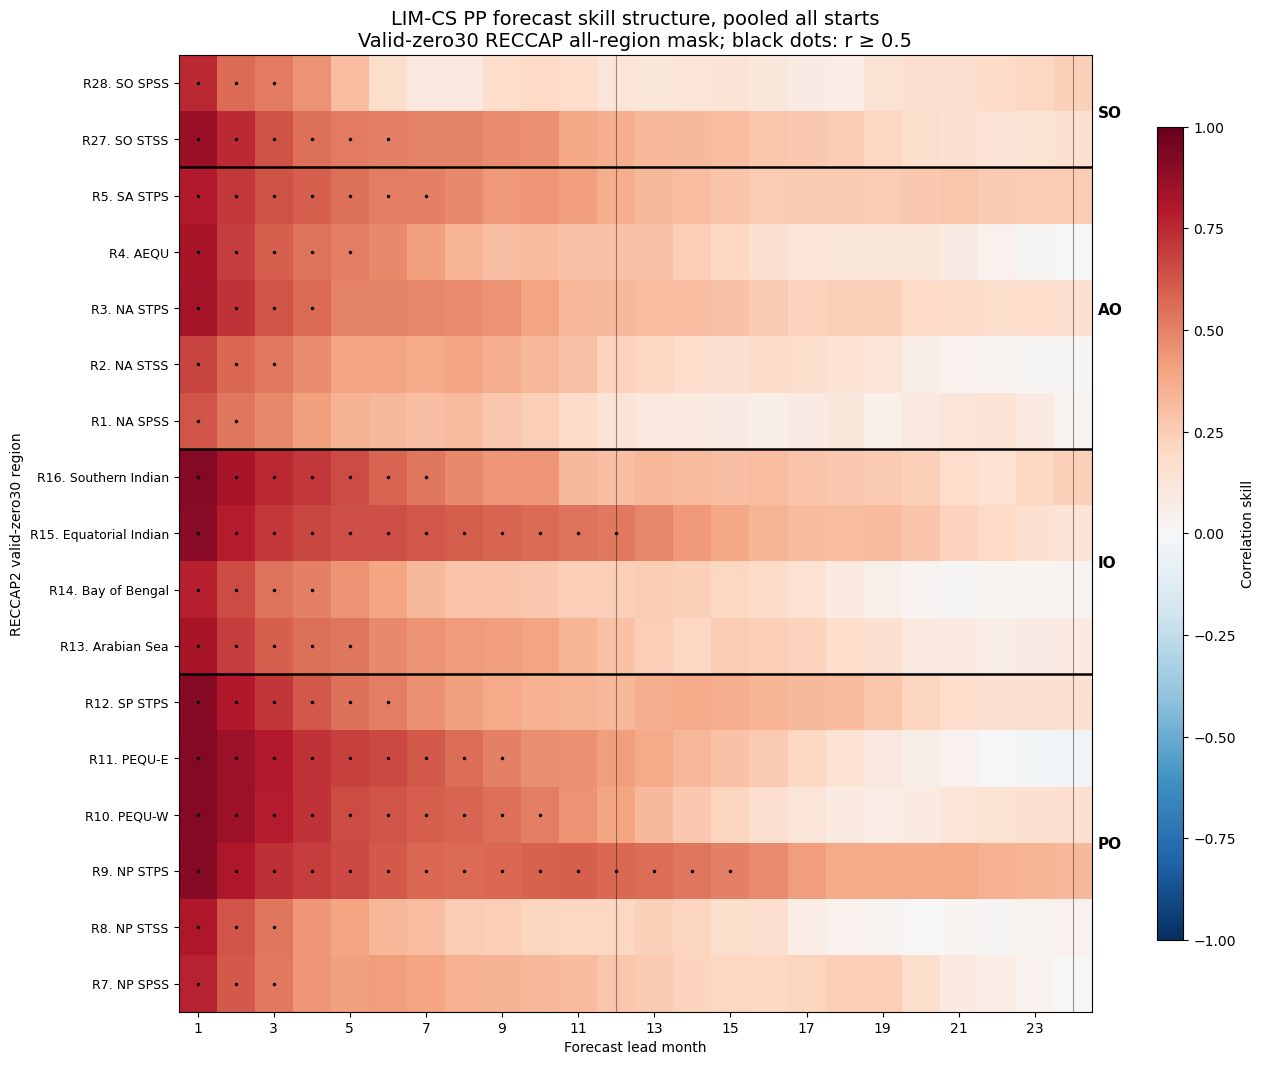

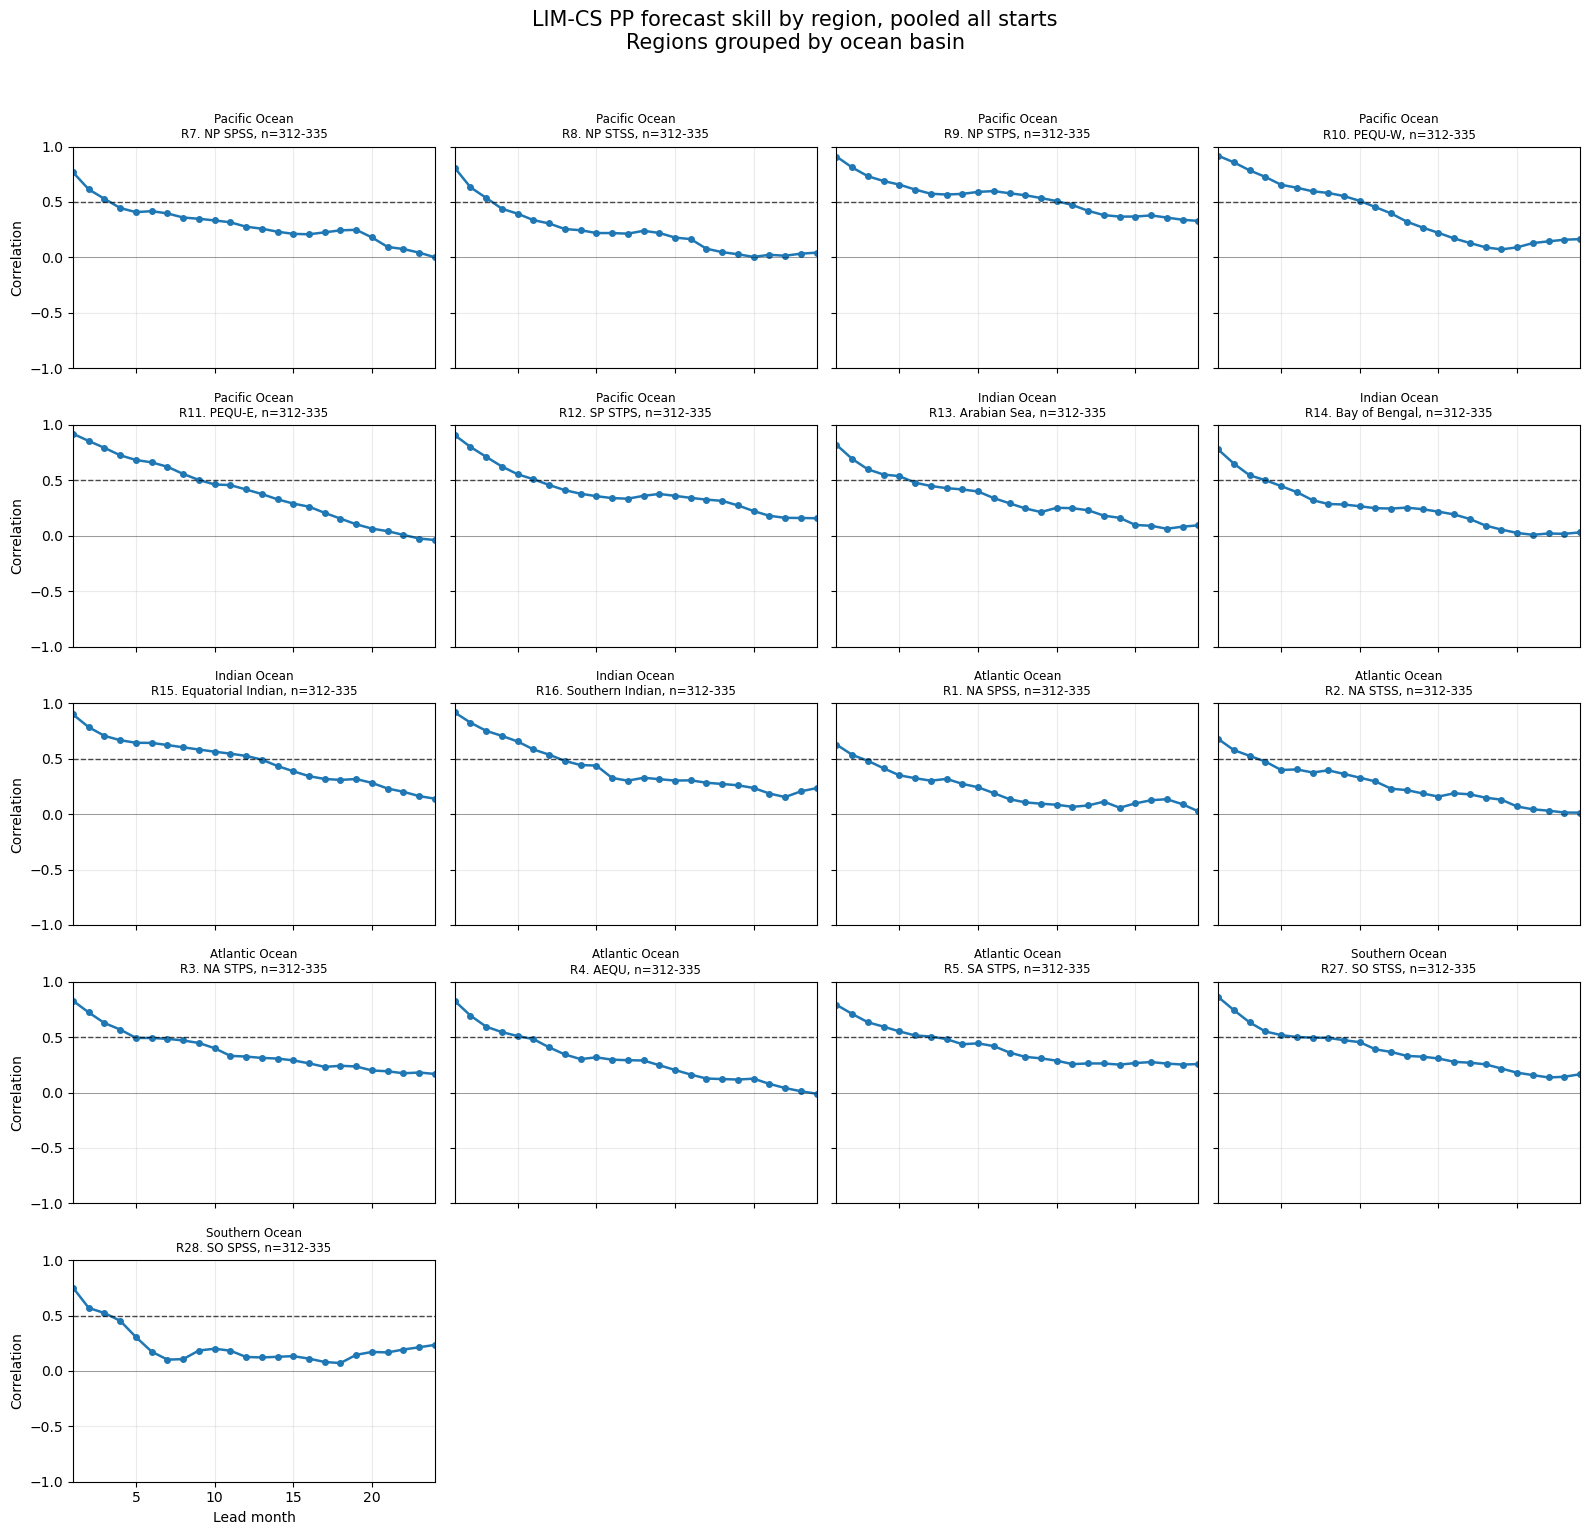

In [20]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# Settings
# ============================================================

SKILL_FILE = (
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill/"
    "Cyclostationary_LIM_PP_forecast_skill_24month_corr_threshold05_"
    "RECCAP2_all_regions_valid_zero30.nc"
)

OUT_DIR = Path("/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill")
OUT_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD = 0.5

FIG_HEATMAP = OUT_DIR / (
    "LIM_CS_PP_skill_structure_pooled_all_starts_"
    "valid_zero30_allregions_heatmap.png"
)

FIG_LINES = OUT_DIR / (
    "LIM_CS_PP_skill_structure_pooled_all_starts_"
    "valid_zero30_allregions_regional_lines.png"
)

BASIN_SHORT = {
    "Pacific Ocean": "PO",
    "Indian Ocean": "IO",
    "Atlantic Ocean": "AO",
    "Southern Ocean": "SO",
    "Arctic Ocean": "ArO",
}

# ============================================================
# Helper functions
# ============================================================

def latest_any_1d(r, threshold=0.5):
    """
    Latest lead where r >= threshold anywhere.
    Can be affected by isolated late-lead spikes.
    """
    r = np.asarray(r, dtype=float)
    good = np.where(np.isfinite(r) & (r >= threshold))[0]

    if len(good) == 0:
        return 0

    return int(good.max() + 1)


def latest_contiguous_1d(r, threshold=0.5):
    """
    Latest lead up to which r remains continuously >= threshold
    from lead 1 onward.
    """
    r = np.asarray(r, dtype=float)
    good = np.isfinite(r) & (r >= threshold)

    if len(good) == 0:
        return 0

    if not good[0]:
        return 0

    bad = np.where(~good)[0]

    if len(bad) == 0:
        return int(len(good))

    return int(bad[0])


def decode_str(v):
    """
    Decode netCDF string / byte-string scalar.
    """
    if isinstance(v, bytes):
        return v.decode("utf-8")

    arr = np.asarray(v)

    if arr.shape == ():
        item = arr.item()

        if isinstance(item, bytes):
            return item.decode("utf-8")

        return str(item)

    return str(v)


def get_region_label(ds, reg, short=True):
    """
    Region label for plotting.
    """
    reg = int(reg)

    if "region_name" in ds:
        try:
            name = decode_str(ds["region_name"].sel(region=reg).values)
        except Exception:
            name = f"region {reg}"
    else:
        name = f"region {reg}"

    if "basin" in ds:
        try:
            basin = decode_str(ds["basin"].sel(region=reg).values)
        except Exception:
            basin = ""
    else:
        basin = ""

    if "original_region_id" in ds:
        try:
            original_id = int(ds["original_region_id"].sel(region=reg).values)
        except Exception:
            original_id = -999
    else:
        original_id = -999

    if short:
        return f"R{reg}. {name}"

    if basin != "" and original_id > 0:
        return f"R{reg}. {basin}:{original_id} {name}"

    return f"R{reg}. {name}"


# ============================================================
# Load pooled skill
# ============================================================

ds_skill = xr.open_dataset(SKILL_FILE)

r_pool = ds_skill["PP_correlation_skill"]   # region, lead
n_pool = ds_skill["n_pairs"]                # region, lead

regions = r_pool["region"].values.astype(np.int16)
leads = r_pool["lead"].values.astype(np.int16)

n_region = len(regions)

# ============================================================
# Exclude selected regions and sort by basin
# ============================================================

EXCLUDE_REGIONS = [6, 18, 19, 29]

keep_regions = [
    int(reg) for reg in r_pool["region"].values
    if int(reg) not in EXCLUDE_REGIONS
]

r_pool = r_pool.sel(region=keep_regions)
n_pool = n_pool.sel(region=keep_regions)

# Basin order for plotting
BASIN_ORDER = [
    "Pacific Ocean",
    "Indian Ocean",
    "Atlantic Ocean",
    "Southern Ocean",
    "Arctic Ocean",
]


def get_basin_name(ds, reg):
    """
    Read basin name and convert it to one of the five standard ocean names.
    """
    if "basin" not in ds:
        return "Unknown"

    try:
        raw = decode_str(
            ds["basin"].sel(region=int(reg)).values
        ).strip()
    except Exception:
        return "Unknown"

    name = raw.lower()

    if "pacific" in name:
        return "Pacific Ocean"

    if "indian" in name:
        return "Indian Ocean"

    if "atlantic" in name:
        return "Atlantic Ocean"

    if "southern" in name:
        return "Southern Ocean"

    if "arctic" in name:
        return "Arctic Ocean"

    return raw


# Basin name attached to each retained region
region_basin = {
    int(reg): get_basin_name(ds_skill, reg)
    for reg in keep_regions
}

# Sort regions by basin, retaining original region order within basin
basin_rank = {name: i for i, name in enumerate(BASIN_ORDER)}

regions = np.array(
    sorted(
        keep_regions,
        key=lambda reg: (
            basin_rank.get(region_basin[reg], len(BASIN_ORDER)),
            reg,
        ),
    ),
    dtype=np.int16,
)

r_pool = r_pool.sel(region=regions)
n_pool = n_pool.sel(region=regions)

n_region = len(regions)

print(ds_skill)
print("\nSelected pooled skill array:")
print(r_pool)

print("\nRegions:")
for reg in regions:
    print(f"  {get_region_label(ds_skill, reg, short=False)}")



# ============================================================
# 1. Heatmap: region x lead, grouped by ocean basin
# ============================================================

fig, ax = plt.subplots(figsize=(14.5, 0.48 * n_region + 3.8))

y_edges = np.arange(n_region + 1)
x_edges = np.arange(leads[0] - 0.5, leads[-1] + 1.5, 1.0)

im = ax.pcolormesh(
    x_edges,
    y_edges,
    r_pool.values,
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
    shading="auto",
)

rr = r_pool.values

# Mark r >= threshold
for ireg, reg in enumerate(regions):
    y = ireg + 0.5

    for ilead, lead in enumerate(leads):
        if np.isfinite(rr[ireg, ilead]) and rr[ireg, ilead] >= THRESHOLD:
            ax.plot(
                lead,
                y,
                "k.",
                markersize=3,
            )

# ------------------------------------------------------------
# Basin grouping information
# ------------------------------------------------------------

basin_groups = []

for basin_name in BASIN_ORDER:
    idx = [
        i for i, reg in enumerate(regions)
        if region_basin[int(reg)] == basin_name
    ]

    if len(idx) > 0:
        basin_groups.append(
            {
                "name": basin_name,
                "start": min(idx),
                "end": max(idx),
            }
        )

# Add thick horizontal lines between basins
for group in basin_groups[:-1]:
    boundary = group["end"] + 1
    ax.axhline(
        boundary,
        color="k",
        lw=1.8,
    )

# ------------------------------------------------------------
# Add basin labels using a secondary y-axis
# ------------------------------------------------------------

basin_centers = [
    0.5 * (group["start"] + group["end"] + 1)
    for group in basin_groups
]

basin_labels = [
    BASIN_SHORT.get(group["name"], group["name"])
    for group in basin_groups
]

ax_basin = ax.twinx()

ax_basin.set_ylim(ax.get_ylim())
ax_basin.set_yticks(basin_centers)
ax_basin.set_yticklabels(
    basin_labels,
    fontsize=10,
    fontweight="bold",
)

ax_basin.tick_params(
    axis="y",
    which="both",
    length=0,
    pad=8,
)

ax_basin.set_ylabel("")

# Hide secondary-axis frame
for spine in ax_basin.spines.values():
    spine.set_visible(False)

ax.axvline(12, color="k", lw=0.8, alpha=0.4)
ax.axvline(24, color="k", lw=0.8, alpha=0.4)

ax_basin.set_ylim(0, n_region)
ax_basin.set_yticks(basin_centers)
ax_basin.set_yticklabels(
    basin_labels,
    fontsize=11,
    fontweight="bold",
)

ax_basin.tick_params(axis="y", which="both", length=0, pad=4)
ax_basin.set_ylabel("")

for spine in ax_basin.spines.values():
    spine.set_visible(False)

ax.set_xlim(leads[0] - 0.5, leads[-1] + 0.5)
ax.set_ylim(0, n_region)

ax.set_xlabel("Forecast lead month")
ax.set_ylabel("RECCAP2 valid-zero30 region")

ax.set_title(
    f"LIM-CS PP forecast skill structure, pooled all starts\n"
    f"Valid-zero30 RECCAP all-region mask; black dots: r ≥ {THRESHOLD}",
    fontsize=14,
)

ax.set_xticks(np.arange(1, leads[-1] + 1, 2))

ax.set_yticks(np.arange(n_region) + 0.5)
ax.set_yticklabels(
    [get_region_label(ds_skill, reg, short=True) for reg in regions],
    fontsize=9,
)

# 수동 배치
fig.subplots_adjust(
    left=0.20,
    right=0.83,
    top=0.90,
    bottom=0.10,
)

# 컬러바를 더 가깝게
cax = fig.add_axes([0.875, 0.16, 0.018, 0.68])

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Correlation skill")

plt.show()


# ============================================================
# 2. Regional line panels
# ============================================================

ncol = 4
nrow = int(np.ceil(n_region / ncol))

fig, axes = plt.subplots(
    nrow,
    ncol,
    figsize=(16, 3.0 * nrow),
    sharex=True,
    sharey=True,
)

axes = np.asarray(axes).ravel()

previous_basin = None

for ax, reg in zip(axes, regions):
    r = r_pool.sel(region=reg)
    n = n_pool.sel(region=reg)

    basin = region_basin[int(reg)]
    label = get_region_label(ds_skill, reg, short=True)

    ax.plot(
        leads,
        r,
        marker="o",
        lw=1.8,
        ms=4,
        label="LIM-CS pooled",
    )

    ax.axhline(THRESHOLD, color="k", lw=1.0, ls="--", alpha=0.7)
    ax.axhline(0, color="k", lw=0.6, alpha=0.4)

    ax.set_title(
        f"{basin}\n"
        f"{label}, n={int(n.min())}-{int(n.max())}",
        fontsize=8.5,
    )

    ax.set_xlim(1, leads[-1])
    ax.set_ylim(-1, 1)
    ax.grid(alpha=0.25)

for ax in axes[n_region:]:
    ax.axis("off")

for ax in axes[-ncol:]:
    ax.set_xlabel("Lead month")

for ax in axes[::ncol]:
    ax.set_ylabel("Correlation")

fig.suptitle(
    "LIM-CS PP forecast skill by region, pooled all starts\n"
    "Regions grouped by ocean basin",
    fontsize=15,
    y=1.02,
)

plt.tight_layout()
plt.show()



Skill file:
/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill/Cyclostationary_LIM_PP_forecast_skill_24month_3month_running_mean_corr_threshold05_RECCAP2_all_regions_valid_zero30.nc

Dataset:
<xarray.Dataset>
Dimensions:                               (region: 21, init_time: 336,
                                           lead: 24, init_month: 12)
Coordinates:
  * region                                (region) int16 1 2 3 4 ... 19 27 28 29
  * init_time                             (init_time) datetime64[ns] 1998-01-...
  * lead                                  (lead) int16 1 2 3 4 5 ... 21 22 23 24
  * init_month                            (init_month) int16 1 2 3 ... 10 11 12
Data variables:
    PP_prediction                         (region, init_time, lead) float32 ...
    PP_correlation_skill                  (region, lead) float32 ...
    PP_correlation_skill_by_init_month    (region, init_month, lead) float32 ...
    n_pairs                               (region, lead) int16

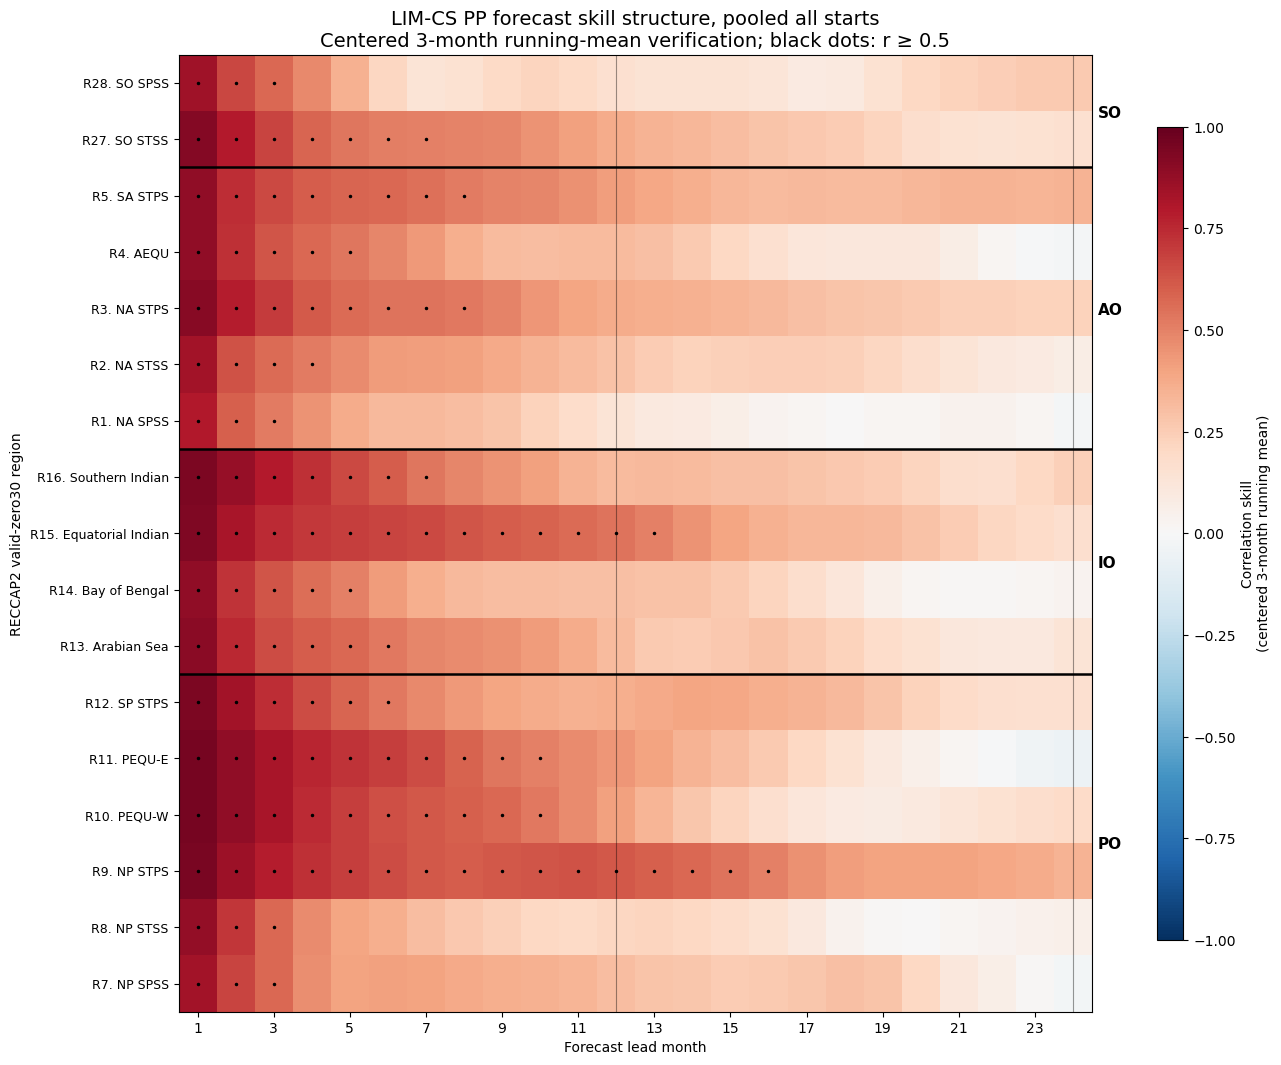

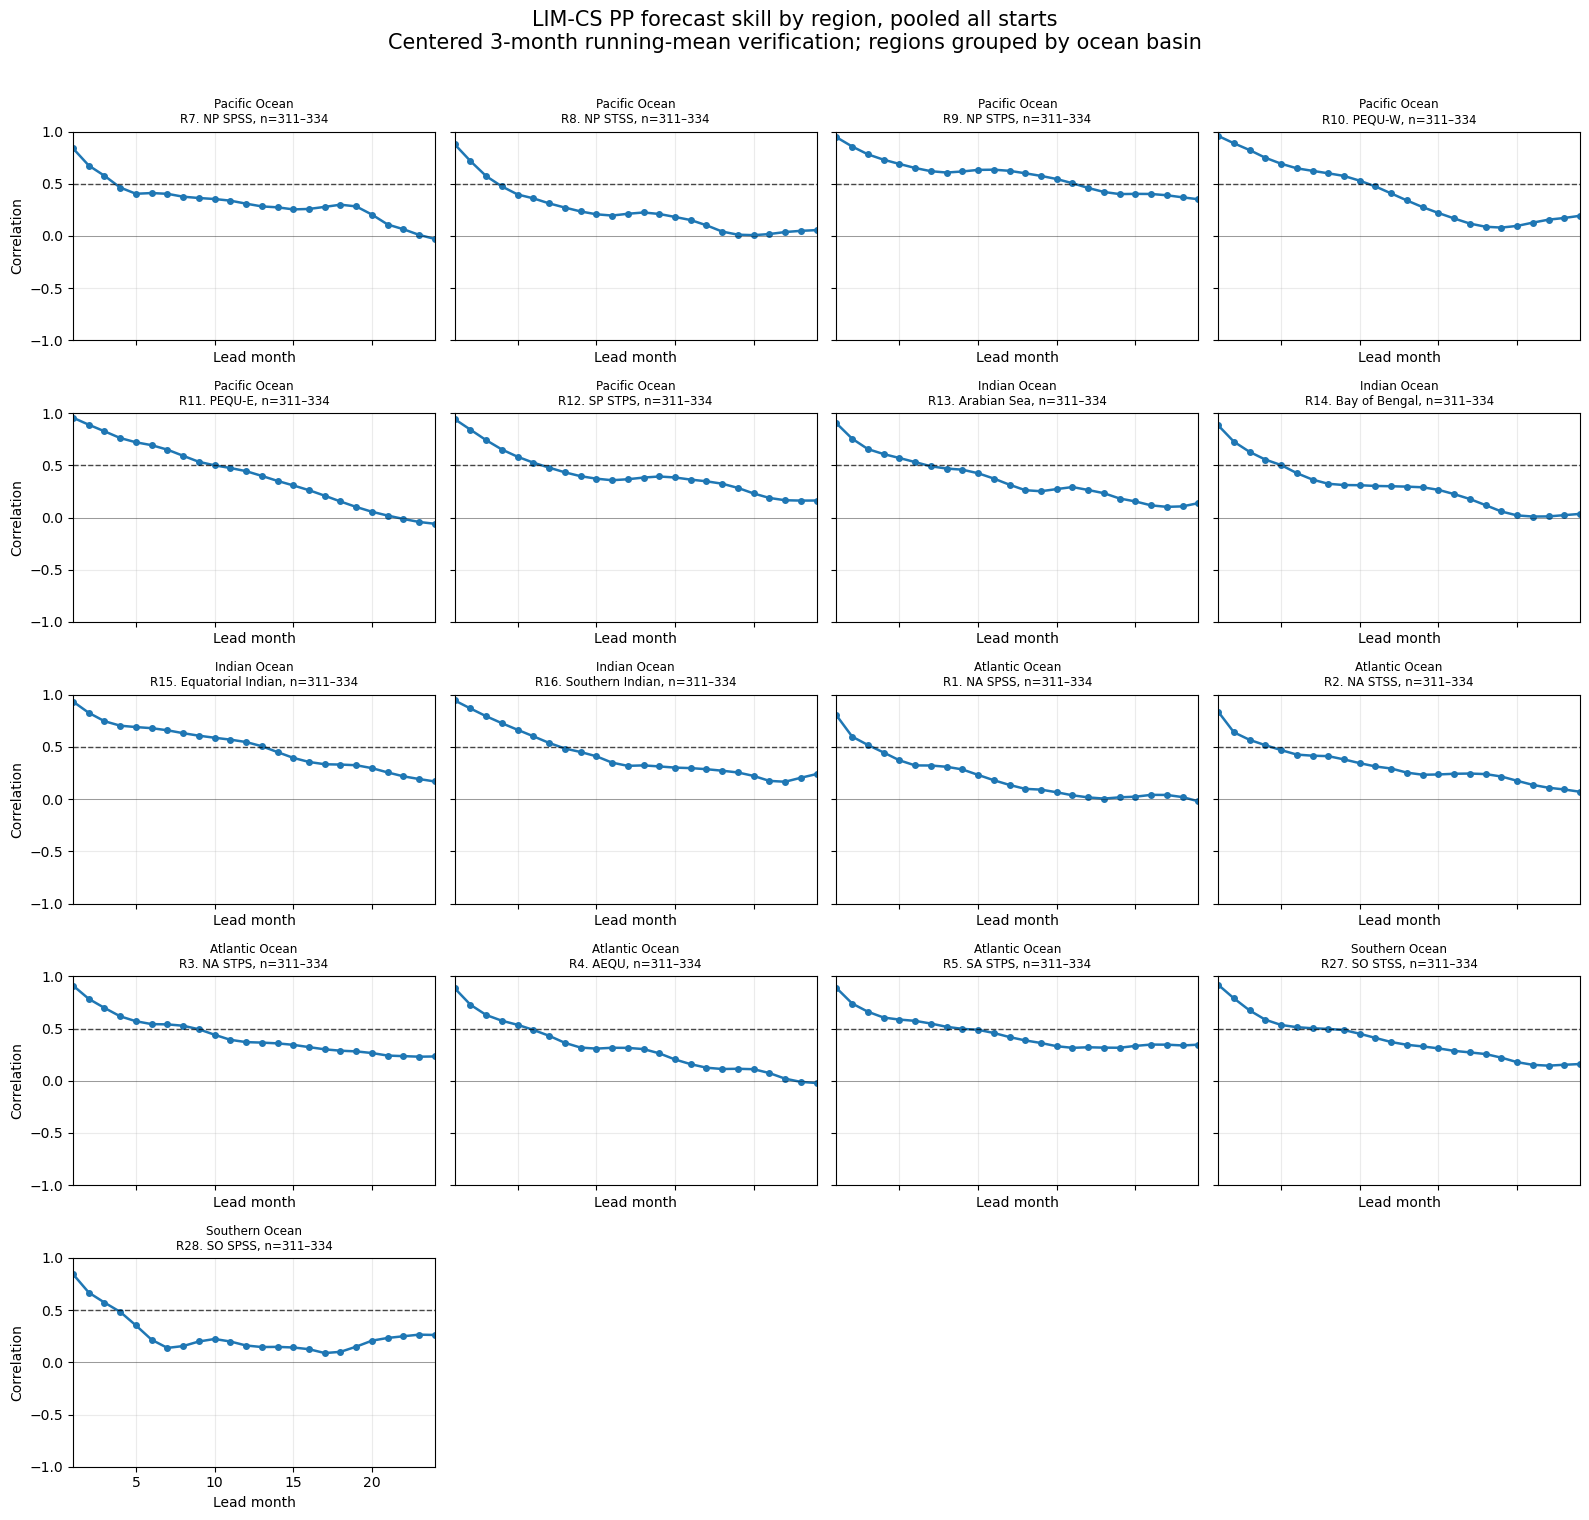

In [21]:
# ============================================================
# LIM-CS PP skill structure using centered 3-month running mean
# pooled across all initialization months
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# Settings
# ============================================================

SKILL_FILE = (
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill/"
    "Cyclostationary_LIM_PP_forecast_skill_24month_"
    "3month_running_mean_corr_threshold05_"
    "RECCAP2_all_regions_valid_zero30.nc"
)

OUT_DIR = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD = 0.5

# Regions excluded only from these figures
EXCLUDE_REGIONS = [6, 18, 19, 29]

FIG_HEATMAP = OUT_DIR / (
    "LIM_CS_PP_skill_structure_3month_running_mean_"
    "pooled_all_starts_valid_zero30_allregions_heatmap.png"
)

FIG_LINES = OUT_DIR / (
    "LIM_CS_PP_skill_structure_3month_running_mean_"
    "pooled_all_starts_valid_zero30_allregions_regional_lines.png"
)

BASIN_SHORT = {
    "Pacific Ocean": "PO",
    "Indian Ocean": "IO",
    "Atlantic Ocean": "AO",
    "Southern Ocean": "SO",
    "Arctic Ocean": "ArO",
}

BASIN_ORDER = [
    "Pacific Ocean",
    "Indian Ocean",
    "Atlantic Ocean",
    "Southern Ocean",
    "Arctic Ocean",
]


# ============================================================
# Helper functions
# ============================================================

def decode_str(v):
    """
    Decode a netCDF string or byte-string scalar.
    """
    if isinstance(v, bytes):
        return v.decode("utf-8")

    arr = np.asarray(v)

    if arr.shape == ():
        item = arr.item()

        if isinstance(item, bytes):
            return item.decode("utf-8")

        return str(item)

    return str(v)


def get_region_label(ds, reg, short=True):
    """
    Return the region label used in plots.
    """
    reg = int(reg)

    if "region_name" in ds:
        try:
            name = decode_str(
                ds["region_name"].sel(region=reg).values
            )
        except Exception:
            name = f"region {reg}"
    else:
        name = f"region {reg}"

    if "basin" in ds:
        try:
            basin = decode_str(
                ds["basin"].sel(region=reg).values
            )
        except Exception:
            basin = ""
    else:
        basin = ""

    if "original_region_id" in ds:
        try:
            original_id = int(
                ds["original_region_id"]
                .sel(region=reg)
                .values
            )
        except Exception:
            original_id = -999
    else:
        original_id = -999

    if short:
        return f"R{reg}. {name}"

    if basin != "" and original_id > 0:
        return f"R{reg}. {basin}:{original_id} {name}"

    return f"R{reg}. {name}"


def get_basin_name(ds, reg):
    """
    Read the basin name and convert it to one of the five
    standard ocean names.
    """
    if "basin" not in ds:
        return "Unknown"

    try:
        raw = decode_str(
            ds["basin"].sel(region=int(reg)).values
        ).strip()
    except Exception:
        return "Unknown"

    name = raw.lower()

    if "pacific" in name:
        return "Pacific Ocean"

    if "indian" in name:
        return "Indian Ocean"

    if "atlantic" in name:
        return "Atlantic Ocean"

    if "southern" in name:
        return "Southern Ocean"

    if "arctic" in name:
        return "Arctic Ocean"

    return raw


# ============================================================
# Check file
# ============================================================

if not Path(SKILL_FILE).exists():
    raise FileNotFoundError(
        "The centered 3-month running-mean skill file "
        f"was not found:\n{SKILL_FILE}"
    )


# ============================================================
# Load pooled 3-month running-mean skill
# ============================================================

ds_skill = xr.open_dataset(SKILL_FILE)

required_variables = [
    "PP_correlation_skill",
    "n_pairs",
]

for var_name in required_variables:
    if var_name not in ds_skill:
        raise KeyError(
            f"{var_name} was not found in:\n{SKILL_FILE}"
        )

# Both variables are based on centered 3-month running-mean
# forecast and observed PP.
r_pool = ds_skill["PP_correlation_skill"]   # region, lead
n_pool = ds_skill["n_pairs"]                # region, lead

leads = r_pool["lead"].values.astype(np.int16)


# ============================================================
# Exclude selected regions
# ============================================================

keep_regions = [
    int(reg)
    for reg in r_pool["region"].values
    if int(reg) not in EXCLUDE_REGIONS
]

r_pool = r_pool.sel(region=keep_regions)
n_pool = n_pool.sel(region=keep_regions)


# ============================================================
# Identify basin for each retained region
# ============================================================

region_basin = {
    int(reg): get_basin_name(ds_skill, reg)
    for reg in keep_regions
}


# ============================================================
# Sort regions by basin
# ============================================================

basin_rank = {
    basin_name: i
    for i, basin_name in enumerate(BASIN_ORDER)
}

regions = np.array(
    sorted(
        keep_regions,
        key=lambda reg: (
            basin_rank.get(
                region_basin[reg],
                len(BASIN_ORDER),
            ),
            reg,
        ),
    ),
    dtype=np.int16,
)

r_pool = r_pool.sel(region=regions)
n_pool = n_pool.sel(region=regions)

n_region = len(regions)


# ============================================================
# Print summary
# ============================================================

print("Skill file:")
print(SKILL_FILE)

print("\nDataset:")
print(ds_skill)

print("\nSelected centered 3-month running-mean skill:")
print(r_pool)

print("\nRegions:")
for reg in regions:
    print(
        f"  {get_region_label(ds_skill, reg, short=False)}"
    )


# ============================================================
# Basin grouping information
# ============================================================

basin_groups = []

for basin_name in BASIN_ORDER:
    indices = [
        i
        for i, reg in enumerate(regions)
        if region_basin[int(reg)] == basin_name
    ]

    if len(indices) > 0:
        basin_groups.append(
            {
                "name": basin_name,
                "start": min(indices),
                "end": max(indices),
            }
        )

basin_centers = [
    0.5 * (group["start"] + group["end"] + 1)
    for group in basin_groups
]

basin_labels = [
    BASIN_SHORT.get(
        group["name"],
        group["name"],
    )
    for group in basin_groups
]


# ============================================================
# 1. Heatmap: region x lead
# ============================================================

fig, ax = plt.subplots(
    figsize=(14.5, 0.48 * n_region + 3.8)
)

y_edges = np.arange(n_region + 1)

x_edges = np.arange(
    leads[0] - 0.5,
    leads[-1] + 1.5,
    1.0,
)

im = ax.pcolormesh(
    x_edges,
    y_edges,
    r_pool.values,
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
    shading="auto",
)

rr = r_pool.values


# ------------------------------------------------------------
# Mark cells where r >= threshold
# ------------------------------------------------------------

for ireg, reg in enumerate(regions):
    y = ireg + 0.5

    for ilead, lead in enumerate(leads):
        value = rr[ireg, ilead]

        if (
            np.isfinite(value)
            and value >= THRESHOLD
        ):
            ax.plot(
                lead,
                y,
                "k.",
                markersize=3,
            )


# ------------------------------------------------------------
# Thick lines between ocean basins
# ------------------------------------------------------------

for group in basin_groups[:-1]:
    boundary = group["end"] + 1

    ax.axhline(
        boundary,
        color="k",
        lw=1.8,
    )


# ------------------------------------------------------------
# Basin labels on right side
# ------------------------------------------------------------

ax_basin = ax.twinx()

ax_basin.set_ylim(0, n_region)
ax_basin.set_yticks(basin_centers)
ax_basin.set_yticklabels(
    basin_labels,
    fontsize=11,
    fontweight="bold",
)

ax_basin.tick_params(
    axis="y",
    which="both",
    length=0,
    pad=4,
)

ax_basin.set_ylabel("")

for spine in ax_basin.spines.values():
    spine.set_visible(False)


# ------------------------------------------------------------
# Reference lead lines
# ------------------------------------------------------------

if leads[-1] >= 12:
    ax.axvline(
        12,
        color="k",
        lw=0.8,
        alpha=0.4,
    )

if leads[-1] >= 24:
    ax.axvline(
        24,
        color="k",
        lw=0.8,
        alpha=0.4,
    )


# ------------------------------------------------------------
# Axes and labels
# ------------------------------------------------------------

ax.set_xlim(
    leads[0] - 0.5,
    leads[-1] + 0.5,
)

ax.set_ylim(0, n_region)

ax.set_xlabel("Forecast lead month")

ax.set_ylabel(
    "RECCAP2 valid-zero30 region"
)

ax.set_title(
    "LIM-CS PP forecast skill structure, pooled all starts\n"
    "Centered 3-month running-mean verification; "
    f"black dots: r ≥ {THRESHOLD}",
    fontsize=14,
)

ax.set_xticks(
    np.arange(
        leads[0],
        leads[-1] + 1,
        2,
    )
)

ax.set_yticks(
    np.arange(n_region) + 0.5
)

ax.set_yticklabels(
    [
        get_region_label(
            ds_skill,
            reg,
            short=True,
        )
        for reg in regions
    ],
    fontsize=9,
)


# ------------------------------------------------------------
# Figure and colorbar position
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.20,
    right=0.83,
    top=0.90,
    bottom=0.10,
)

cax = fig.add_axes(
    [0.875, 0.16, 0.018, 0.68]
)

cbar = fig.colorbar(
    im,
    cax=cax,
)

cbar.set_label(
    "Correlation skill\n"
    "(centered 3-month running mean)"
)

plt.show()

# fig.savefig(
#     FIG_HEATMAP,
#     dpi=200,
#     bbox_inches="tight",
# )
# print(f"Saved: {FIG_HEATMAP}")


# ============================================================
# 2. Regional line panels
# ============================================================

ncol = 4
nrow = int(
    np.ceil(n_region / ncol)
)

fig, axes = plt.subplots(
    nrow,
    ncol,
    figsize=(16, 3.0 * nrow),
    sharex=True,
    sharey=True,
)

axes = np.asarray(axes).ravel()


for ax, reg in zip(axes, regions):
    r = r_pool.sel(region=reg)
    n = n_pool.sel(region=reg)

    basin = region_basin[int(reg)]

    label = get_region_label(
        ds_skill,
        reg,
        short=True,
    )

    ax.plot(
        leads,
        r.values,
        marker="o",
        lw=1.8,
        ms=4,
        label="LIM-CS pooled, 3-month mean",
    )

    ax.axhline(
        THRESHOLD,
        color="k",
        lw=1.0,
        ls="--",
        alpha=0.7,
    )

    ax.axhline(
        0,
        color="k",
        lw=0.6,
        alpha=0.4,
    )

    finite_n = n.values[
        np.isfinite(n.values)
    ]

    if finite_n.size > 0:
        n_text = (
            f"n={int(np.nanmin(finite_n))}"
            f"–{int(np.nanmax(finite_n))}"
        )
    else:
        n_text = "n=NA"

    ax.set_title(
        f"{basin}\n"
        f"{label}, {n_text}",
        fontsize=8.5,
    )

    ax.set_xlim(
        leads[0],
        leads[-1],
    )

    ax.set_ylim(-1, 1)

    ax.grid(
        alpha=0.25
    )


# Hide unused axes
for ax in axes[n_region:]:
    ax.axis("off")


# X-axis labels
for ax in axes:
    if ax.get_visible():
        ax.set_xlabel(
            "Lead month"
        )


# Y-axis labels on first column
for i, ax in enumerate(axes[:n_region]):
    if i % ncol == 0:
        ax.set_ylabel(
            "Correlation"
        )


fig.suptitle(
    "LIM-CS PP forecast skill by region, pooled all starts\n"
    "Centered 3-month running-mean verification; "
    "regions grouped by ocean basin",
    fontsize=15,
    y=1.01,
)

plt.tight_layout()

plt.show()

# fig.savefig(
#     FIG_LINES,
#     dpi=200,
#     bbox_inches="tight",
# )
# print(f"Saved: {FIG_LINES}")


# ============================================================
# Close dataset
# ============================================================

ds_skill.close()